# Capstone Project — Forecasting Food Prices in Kenyan Markets
### Quantifying Uncertainty in Kenyan Staple Food Prices

## 1. Problem Definition

### Problem Statement

Households, traders and humanitarian agencies in Kenya make decisions — when to buy,
when to release stock, how much cash assistance to transfer — against food prices they
cannot see in advance. Prices are observed only after the fact, published monthly with a
reporting lag, and by the time a sharp increase is visible in the data the decisions it
should have informed have already been made.

This project asks a narrow, testable question:

> **Can next month's staple food price in a given Kenyan market be forecast from
> information observable at the time of prediction, and does a machine-learning model
> that pools information across many markets outperform classical time-series models
> fitted to each market separately?**

The target is the monthly price of a staple commodity in a specific market, normalised to
KES per kilogram, forecast one month ahead. The benchmark every model must beat is the
naive forecast — next month equals this month — which for a price series with a unit root
is the theoretically optimal one-step prediction and therefore a demanding bar rather
than a formality.

### Why the Problem Is Important

Food accounts for roughly a third of the Kenyan consumer price index, and staple prices
are the single largest driver of short-run changes in household purchasing power. The
consequences of unanticipated price movements fall hardest on the households least able
to absorb them.

The problem is acute in the two market systems this project examines:

- **Refugee camp and settlement markets** (Kakuma, Kalobeyei, Dadaab) where the World Food
  Programme sets cash-transfer values against observed market prices. If prices rise
  between the observation and the transfer, the transfer under-delivers in real terms.
- **Commercial wholesale markets** (Nairobi, Mombasa, Kisumu, Eldoret) which set the
  reference prices that propagate through the national retail system.

A month of advance warning is not a large amount of time, but it is the difference
between reacting to a price rise and preparing for one.

### Expected Impact

The deliverable is a month-ahead price forecast for each covered market–commodity series,
reported as a point estimate with a prediction interval, together with an honest account
of how accurate those forecasts are and where they fail.

The evaluation determines which of two things this project produces. Either a model
improves on the naive benchmark, in which case the point forecast is the contribution; or
it does not, in which case the contribution is the **calibrated interval** — a quantified
statement of how much a price could move, where none currently exists. Both are useful
outputs; they are useful to different degrees and in different ways, and the analysis is
designed to establish which applies rather than to assume the first.

Realistically, the impact is bounded either way:

- **What it can do** — replace an unquantified expectation with a quantified one, carrying
  an explicit uncertainty range, for a specific set of markets and commodities.
- **What it cannot do** — forecast prices in markets it has no data for, anticipate regime
  changes such as an administered price beginning to move, or address food insecurity,
  which depends on household income and market access as much as on price.

A model presented as more capable than the evidence supports would be misleading. The
purpose of Sections 6 and 7 is to establish, out of sample and with significance testing,
exactly which claims the data will bear.

### Why the Dataset Was Selected

The World Food Programme's Kenya food-price database, published through the Humanitarian
Data Exchange, was chosen over the alternatives because it records **directly observed
prices**. The World Bank's Real-Time Food Prices dataset covers the same country over a
longer period with better documentation, but it is compiled partly by machine-learning
imputation of missing values. Forecasting it would mean training a model to predict
another model's output, and its imputation may draw on information from after the month
being imputed — leakage that cannot be detected or removed. WFP data is used as the
primary source for that reason; the assessment of its structure and quality occupies
Sections 2 to 5 of this notebook.


### Setup


In [ ]:
!pip install xgboost statsmodels shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
from scipy import stats
import requests

from io import StringIO

# Standard settings
plt.style.use('fivethirtyeight')
%matplotlib inline

## Data Loading and Inspection


In [ ]:
# Identify the WFP Kenya dataset
dataset_name = "wfp-food-prices-for-kenya"

api_url = "https://data.humdata.org/api/3/action/package_show"

response = requests.get(
    api_url,
    params={"id": dataset_name}
)

response.raise_for_status()

dataset_info = response.json()

dataset_info["success"]

True

In [ ]:
#explore all resources in the api endpoint
resources = dataset_info["result"]["resources"]

for resource in resources:
    print(
        "Name:", resource.get("name"),
        "\nID:", resource.get("id"),
        "\nFormat:", resource.get("format"),
        "\nURL:", resource.get("url"),
        "\n"
    )

Name: Kenya - Food Prices 
ID: 517ee1bf-2437-4f8c-aa1b-cb9925b9d437 
Format: CSV 
URL: https://data.humdata.org/dataset/e0d3fba6-f9a2-45d7-b949-140c455197ff/resource/517ee1bf-2437-4f8c-aa1b-cb9925b9d437/download/wfp_food_prices_ken.csv 

Name: Kenya - Markets 
ID: fde6f6c7-9776-4b52-a826-d77f9d3f6688 
Format: CSV 
URL: https://data.humdata.org/dataset/e0d3fba6-f9a2-45d7-b949-140c455197ff/resource/fde6f6c7-9776-4b52-a826-d77f9d3f6688/download/wfp_markets_ken.csv 



In [ ]:
# This cell defines a function to load WFP Kenya food-price data, handling download and local caching.
import hashlib
from pathlib import Path

import pandas as pd
import requests


def load_wfp_data(path="data/raw/wfp_kenya.csv", refresh=False):
    """Load the WFP Kenya food-price CSV, downloading once from HDX.

    The file is fetched only if it is missing or refresh=True, so the
    dataset stays frozen while you model against it.

    Returns:
        df   - DataFrame
        meta - dict with path, sha256, retrieved flag, and resource info
    """
    path = Path(path)

    if path.exists() and not refresh:
        raw = path.read_bytes()
        resource = None
        retrieved = False
    else:
        response = requests.get(
            "https://data.humdata.org/api/3/action/package_show",
            params={"id": "wfp-food-prices-for-kenya"},
            timeout=60,
        )
        response.raise_for_status()

        dataset_info = response.json()
        if not dataset_info.get("success"):
            raise RuntimeError("HDX API did not return a successful response.")

        resource = next(
            (
                r
                for r in dataset_info["result"]["resources"]
                if r.get("format", "").strip().lower() == "csv"
                and r.get("name", "").strip().lower() == "kenya - food prices"
            ),
            None,
        )
        if resource is None:
            raise ValueError("Kenya - Food Prices CSV resource was not found.")

        download = requests.get(resource["url"], timeout=60)
        download.raise_for_status()
        raw = download.content

        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(raw)
        retrieved = True

    df = pd.read_csv(path)

    meta = {
        "path": str(path),
        "sha256": hashlib.sha256(raw).hexdigest(),
        "n_rows": len(df),
        "retrieved": retrieved,
        "resource_id": resource["id"] if resource else None,
        "resource_url": resource["url"] if resource else None,
    }
    return df, meta

In [ ]:
# verfies if data is from local cache or from downloaded
df, meta = load_wfp_data()
print(meta["sha256"][:12], "|", meta["n_rows"], "rows |", "downloaded" if meta["retrieved"] else "from disk")

92f21327bd01 | 27763 rows | downloaded


In [ ]:
#basic data inspection
print("--- First 5 rows ---")
print(df.head())

print("\n--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
#df.describe(include='all')

df.isna().sum()

--- First 5 rows ---
         date   admin1   admin2   market  market_id  latitude  longitude  \
0  2006-01-15    Coast  Mombasa  Mombasa        191     -4.05      39.67   
1  2006-01-15    Coast  Mombasa  Mombasa        191     -4.05      39.67   
2  2006-01-15    Coast  Mombasa  Mombasa        191     -4.05      39.67   
3  2006-01-15  Eastern    Kitui    Kitui        187     -1.37      38.02   
4  2006-01-15  Eastern    Kitui    Kitui        187     -1.37      38.02   

             category         commodity  commodity_id   unit priceflag  \
0  cereals and tubers     Maize (white)            67  90 KG    actual   
1     pulses and nuts             Beans            50     KG    actual   
2     pulses and nuts       Beans (dry)           262  90 KG    actual   
3  cereals and tubers     Maize (white)            67     KG    actual   
4  cereals and tubers  Potatoes (Irish)           148  50 KG    actual   

   pricetype currency    price  usdprice  
0  Wholesale      KES  1480.00    

,0
date,0
admin1,62
admin2,62
market,0
market_id,0
latitude,62
longitude,62
category,0
commodity,0
commodity_id,0


In [ ]:
print("Unique markets:", df["market"].nunique())
print("Unique commodities:", df["commodity"].nunique())
print("Unique dates:", df["date"].nunique())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())
market_commodity = (
    df.groupby(["market", "commodity"])
      .agg(
          observations=("date", "count"),
          first_date=("date", "min"),
          last_date=("date", "max")
      )
      .reset_index()
      .sort_values("observations", ascending=False)
)

print(market_commodity.head(20))

Unique markets: 226
Unique commodities: 51
Unique dates: 248

Date range:
2006-01-15 to 2026-08-15
                          market                commodity  observations  \
2384                     Nairobi                    Maize           190   
451   Eldoret town (Uasin Gishu)                    Maize           188   
1458                       Kitui            Maize (white)           180   
1457                       Kitui              Beans (dry)           180   
2378                     Nairobi                    Bread           178   
2389                     Nairobi  Milk (cow, pasteurized)           178   
2390                     Nairobi          Oil (vegetable)           178   
2377                     Nairobi              Beans (dry)           171   
2103                    Marsabit            Maize (white)           171   
452   Eldoret town (Uasin Gishu)            Maize (white)           170   
2385                     Nairobi            Maize (white)           170   
2

### Data Inspection Summary

The WFP food prices dataset contains **28,062 entries** and **16 columns**. Key observations from the inspection are:

*   **Data Types**: The `date` column is currently an `object` type and will need to be converted to a proper datetime format for time-series analysis.
*   **Missing Values**: There are a small number of missing values (68 entries) in the `admin1`, `admin2`, `latitude`, and `longitude` columns. These will need to be addressed during data cleaning.
*   **Categorical Columns**: There are 248 unique dates, 7 unique `admin1` regions, 27 unique `admin2` regions, and 226 unique `market` entries. The data spans 8 `category` types, 51 `commodity` types, 13 `unit` types, 3 `priceflag` types, 2 `pricetype` types, and prices are uniformly in `KES` currency.
*   **Numerical Columns**: The `market_id`, `latitude`, `longitude`, `commodity_id`, `price`, and `usdprice` columns are numerical. The `price` column has a wide range, from 5.0 to 19800.0 KES, with a mean of approximately 1303.49 KES. The `usdprice` shows a similar spread, with a mean of around 11.92 USD.

In [ ]:
# Convert the 'date' column to datetime objects to facilitate time-series analysis
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

datetime64[ns]


### Price Series Data Quality Assessment

###Series dataframe

In [ ]:
KEY = [
    "market_id",
    "market",
    "commodity",
    "pricetype",
    "unit",
    "currency"
]

series = (
    df.groupby(KEY)
    .agg(
        n_obs=("price", "size"),
        n_valid_price=("price", "count"),
        n_months=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .reset_index()
)

series["span_months"] = (
    (series["last_date"].dt.year - series["first_date"].dt.year) * 12
    + (series["last_date"].dt.month - series["first_date"].dt.month)
    + 1
)

series["density"] = (
    series["n_months"] / series["span_months"]
)

display(series.head())

,market_id,market,commodity,pricetype,unit,currency,n_obs,n_valid_price,n_months,first_date,last_date,span_months,density
0,184,Nairobi,Bananas,Retail,Unit,KES,1,1,1,2020-08-15,2020-08-15,1,1.000000
1,184,Nairobi,Beans,Wholesale,KG,KES,144,144,144,2006-01-15,2021-11-15,191,0.753927
2,184,Nairobi,Beans (dry),Retail,KG,KES,1,1,1,2020-08-15,2020-08-15,1,1.000000
3,184,Nairobi,Beans (dry),Wholesale,90 KG,KES,170,170,170,2006-01-15,2020-03-15,171,0.994152
4,184,Nairobi,Bread,Retail,400 G,KES,178,178,178,2006-01-15,2020-12-15,180,0.988889


The data is aggregated at this series level to profile the historical coverage and continuity of each candidate forecasting series. The following metrics are calculated:

n_obs: Total number of observations in the series.
n_valid_price: Number of observations with a non-missing price.
n_months: Number of unique months in which the series has observations.
first_date: Earliest recorded observation for the series.
last_date: Most recent recorded observation for the series.
span_months: Total calendar duration, in months, between the first and last observation.
density: The proportion of months within the series' observed time span that contain data, calculated as n_months / span_months.

This series-level profile provides the foundation for assessing historical coverage, temporal continuity, missingness, and recency before selecting candidate series for forecasting models.

###Distribution of entries end years across different months bins

In [ ]:

pd.set_option("display.max_rows", 100)

series["end_year"] = series["last_date"].dt.year
series["len_band"] = pd.cut(series["n_months"], [0,12,36,60,120,1000],
                            labels=["<12","12-35","36-59","60-119","120+"], right=False)

print(pd.crosstab(series["end_year"], series["len_band"], margins=True))

len_band   <12  12-35  36-59  60-119  120+   All
end_year                                        
2012         2      0      0       0     0     2
2019         0      0      0       0     7     7
2020        13      0      1      15    19    48
2021       336      0      0       0     3   339
2022        69     90      0       0     4   163
2023        72     76      0       0     0   148
2024      1037     24      3       0     0  1064
2025       306     10      7       0     0   323
2026       636     52    140       0     0   828
All       2471    252    151      15    33  2922




Before selecting forecasting models, the dataset was assessed to determine two fundamental properties of each price series:

- **Historical depth** — how many months of price observations are available.
- **Recency** — how recently the series continued to report prices.

The assessment revealed a clear structural limitation in the data. Series with at least 120 months of history generally stop reporting by 2022, while series that continue reporting into the more recent period have substantially shorter histories, with at most 59 months available.

In other words, **no series is both long-running and current**.

This means that a single forecasting design would not be appropriate for the entire dataset. Instead, the structure of the available data naturally supports two complementary studies:

- **Study A — Long historical series:** Uses series with extensive historical coverage. The longer time span supports a fuller retrospective evaluation, including the investigation of seasonality and longer forecasting test periods.

- **Study B — Current series:** Uses series that continue reporting into the recent period and are therefore suitable for operational forecasting. Because individual series have shorter histories, the approach can pool information across multiple market–commodity series rather than relying entirely on each series individually.

The two-study design is therefore **imposed by the structure of the data rather than chosen arbitrarily**. It allows each subset to be analysed using methods appropriate to the amount and type of information it contains.

Most of the 2,922 available series are not included in either study because they do not provide sufficient continuity, historical depth, or recent coverage for reliable forecasting. The final study panels are therefore deliberately selected subsets that meet predefined minimum requirements for data quality and forecasting suitability.

###Identification of the Recent Forecasting Cohort

In [ ]:
liveB = series[(series["n_months"] >= 36) & (series["last_date"] >= "2026-01-01")]
spec_cols = ["commodity", "pricetype", "unit", "currency"]

# markets carrying a broad range of specs form the core panel; stragglers carry few
per_market = liveB.groupby("market")[spec_cols].apply(lambda g: len(g.drop_duplicates()))
print(per_market.sort_values(ascending=False).to_string())

MIN_SPECS = 7
core_markets = per_market[per_market >= MIN_SPECS].index
sub = liveB[liveB["market"].isin(core_markets)]

n_markets = sub["market"].nunique()
complete = (sub.groupby(spec_cols)["market"].nunique()
               .loc[lambda s: s == n_markets].index)
core = sub.set_index(spec_cols).loc[complete].reset_index()

print(f"\n{n_markets} core markets | {core['commodity'].nunique()} specs | {len(core)} series")
print(pd.crosstab(core["market"], core["commodity"]))
print(core["n_months"].describe())
print("common window:", core["first_date"].max(), "→", core["last_date"].min())

market
IFO (Daadab)             13
Kakuma 3                 13
Hagadera (Daadab)        12
Kakuma 2                 12
Mogadishu (Kakuma)       11
Kalobeyei (Village 1)    11
Kakuma 4                 11
Ethiopia (Kakuma)        10
Dagahaley (Daadab)        9
HongKong (Kakuma)         9
Kalobeyei (Village 2)     9
Kalobeyei (Village 3)     9
Kathonzweni (Makueni)     4
Kibuye (Kisumu)           4
Kangemi (Nairobi)         3

12 core markets | 7 specs | 84 series
commodity              Beans (dry)  Maize flour  Oil (vegetable)  Rice  Salt  \
market                                                                         
Dagahaley (Daadab)               1            1                1     1     1   
Ethiopia (Kakuma)                1            1                1     1     1   
Hagadera (Daadab)                1            1                1     1     1   
HongKong (Kakuma)                1            1                1     1     1   
IFO (Daadab)                     1            1       

### Selecting the Study B Panel

Study B focuses on the more recent part of the dataset and is intended to examine whether recent price information can be used to forecast future prices.

The initial selection (`liveB`) includes all price series with at least three years of historical data and observations extending into 2026. However, not all markets report the same range of commodities. Some markets consistently report prices for many commodities, while others contain data for only a small number.

To create a meaningful dataset for comparison across markets, the selection is carried out in two steps:

1. **Identify the core markets.** Markets with broader commodity coverage are identified first. These markets form the core of the study because they provide a sufficiently broad and consistent set of price observations. Markets with only a small number of available commodities are excluded from this panel.

2. **Retain common commodity specifications.** Only commodity specifications that are available across all selected core markets are retained. This ensures that the final dataset allows the same commodities to be compared across the same group of markets.

A commodity specification includes not only the commodity name, but also the type of price, unit of measurement, and currency. For example, the retail price of maize per kilogram is treated separately from the wholesale price of maize sold in a 90 kg bag because they represent different market measurements.

The final Study B panel therefore consists of a common set of markets and price specifications observed across the recent study period. This creates a consistent basis for comparing forecasting models across multiple markets.


In [ ]:
#function to identify gaps in the study b panel
def gap_profile(g):
    months = g["date"].dt.to_period("M").sort_values()
    n_dupe = months.duplicated().sum()
    months = months.unique()

    full = pd.period_range(months.min(), months.max(), freq="M")
    missing = full.difference(months)

    if len(missing) == 0:
        return pd.Series({"n_missing": 0, "longest_gap": 0, "n_runs": 0,
                          "n_dupe": n_dupe, "last_gap": None, "gaps": ""})

    runs = pd.Series(missing.astype("int64")).diff().ne(1).cumsum()
    spans = [f"{grp.min()}..{grp.max()}" if len(grp) > 1 else str(grp.min())
             for _, grp in pd.Series(missing).groupby(runs.values)]

    return pd.Series({
        "n_missing": len(missing),
        "longest_gap": runs.value_counts().max(),
        "n_runs": runs.nunique(),
        "n_dupe": n_dupe,
        "last_gap": str(missing.max()),
        "gaps": "; ".join(spans),
    })

### Extracting the panel rows and profiling gaps

In [ ]:
KEYCOLS = ["market_id", "commodity", "pricetype", "unit", "currency"]

B = df.merge(core[KEYCOLS], on=KEYCOLS)
assert len(B) == core["n_obs"].sum(), f"merge changed row count: {len(B)} vs {core['n_obs'].sum()}"

profileB = (B.groupby(["market", "commodity"])
              .apply(gap_profile, include_groups=False).reset_index())
print(profileB["longest_gap"].describe())
print(profileB.nlargest(10, "longest_gap")[
    ["market","commodity","n_missing","longest_gap","gaps"]].to_string(index=False))

count    84.000000
mean     11.511905
std       3.615542
min      10.000000
25%      10.000000
50%      10.000000
75%      12.000000
max      23.000000
Name: longest_gap, dtype: float64
            market       commodity  n_missing  longest_gap                                                                                                       gaps
Dagahaley (Daadab)     Beans (dry)         37           23                                     2019-02..2020-12; 2021-02; 2022-01..2022-10; 2022-12; 2025-04; 2025-08
Dagahaley (Daadab)     Maize flour         37           23                                     2019-02..2020-12; 2021-02; 2022-01..2022-10; 2022-12; 2025-04; 2025-08
Dagahaley (Daadab) Oil (vegetable)         37           23                                     2019-02..2020-12; 2021-02; 2022-01..2022-10; 2022-12; 2025-04; 2025-08
Dagahaley (Daadab)            Rice         37           23                                     2019-02..2020-12; 2021-02; 2022-01..2022-10; 2022-12; 2



The previous step identified the series that belong in the Study B panel. This cell now retrieves the corresponding monthly observations from the full dataset so that the selected panel can be used for forecasting.

A check is included to confirm that the join has not accidentally created duplicate observations. This ensures that the number of observations in the modelling dataset still matches the number expected from the selected series.

The cell also profiles missing months within each series. The aim is to distinguish between **small, scattered gaps** and **long periods with no observations**.

This distinction matters because a series with a few isolated missing months is very different from one that disappears for several consecutive months. Long gaps can break the continuity of the price history and make it difficult to construct reliable time-based forecasting features.

The gap profile therefore helps us identify which series have the most serious continuity problems and whether those gaps could affect the period that is ultimately used for modelling.

Sorting by `longest_gap` brings the most problematic series to the top, while `gaps` shows the specific periods responsible. This gives us evidence for deciding how much of the available Study B history can be safely used.

###Visualizing longest gap per year

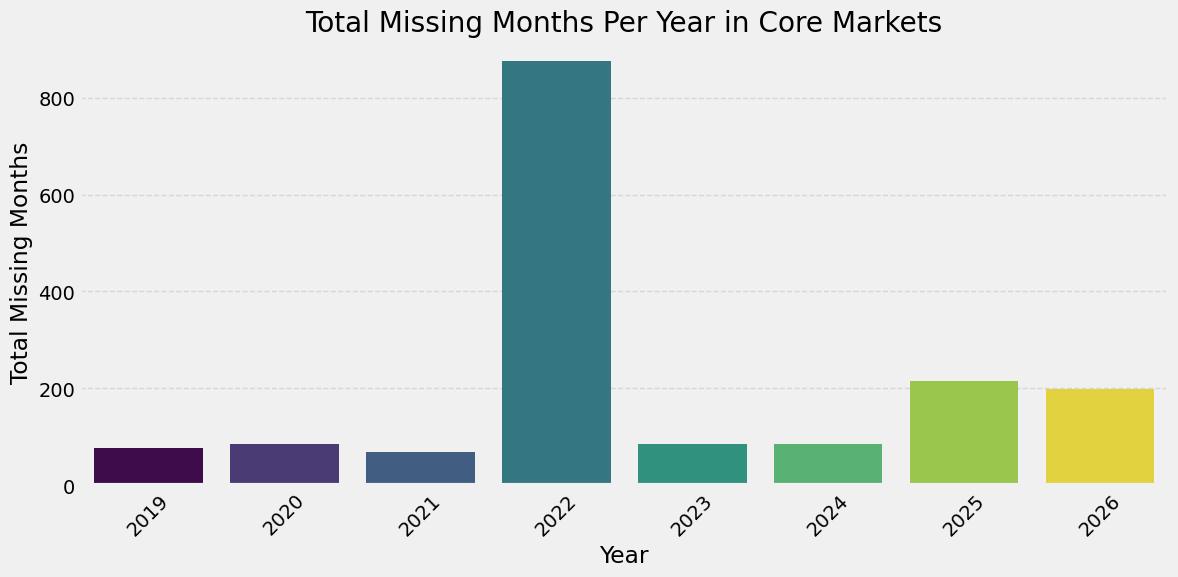

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


allgaps = []
for _, r in profileB.iterrows():
    if r["gaps"]:
        for span in r["gaps"].split("; "):
            for p in (pd.period_range(*span.split("..", 1), freq="M") if ".." in span else [pd.Period(span, "M")]):
                allgaps.append({"market": r["market"], "commodity": r["commodity"],
                                "period": p, "month": p.month, "year": p.year})

g = pd.DataFrame(allgaps)

# Group by year and count the number of missing months (gaps)
year_missing_months = g.groupby('year')['month'].count().reset_index()
year_missing_months.columns = ['year', 'total_missing_months']

# Create the bar plot
fig = plt.figure(figsize=(12, 6))
sns.barplot(x='year', y='total_missing_months', data=year_missing_months, palette='viridis', hue='year', legend=False)
plt.title('Total Missing Months Per Year in Core Markets')
plt.xlabel('Year')
plt.ylabel('Total Missing Months')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Restricting Study B to a usable window

In [ ]:
Bt = B[B["date"] >= "2023-01-01"].copy()
Bt["month"] = Bt["date"].dt.to_period("M")

prof2 = (Bt.groupby(["market","commodity"])
           .apply(gap_profile, include_groups=False).reset_index())
print(prof2["longest_gap"].describe())
print(prof2["n_missing"].describe())

cnt = Bt.groupby(["market","commodity"]).size().unstack()
print(cnt.to_string())
print("\nwindow:", Bt["month"].min(), "→", Bt["month"].max())

count    84.000000
mean      2.273810
std       1.101491
min       0.000000
25%       2.000000
50%       2.500000
75%       3.000000
max       6.000000
Name: longest_gap, dtype: float64
count    84.000000
mean      6.916667
std       4.243232
min       0.000000
25%       3.000000
50%       7.500000
75%      11.000000
max      16.000000
Name: n_missing, dtype: float64
commodity              Beans (dry)  Maize flour  Oil (vegetable)  Rice  Salt  Sugar  Wheat flour
market                                                                                          
Dagahaley (Daadab)              41           41               41    41    41     41           41
Ethiopia (Kakuma)               33           33               33    33    34     34           33
Hagadera (Daadab)               41           41               41    41    42     42           42
HongKong (Kakuma)               32           33               33    33    35     36           36
IFO (Daadab)                    44           41 



The full Study B history contains long, systematic gaps that make the earlier
period unsuitable for a consistent forecasting panel. The most important gap
occurs around 2022, where many markets stop reporting across multiple
commodities at the same time. This indicates a **market-level interruption in
price collection**, rather than individual commodities randomly disappearing.
Some Dadaab series also contain an extended earlier gap.

Because the objective is to compare forecasting performance across a common
panel, these long interruptions are more important than occasional missing
months. A long gap breaks the continuity of the price history and reduces the
amount of information available for constructing time-based features.

We therefore restrict Study B to **2023 onward**, where the panel becomes
substantially more continuous. This reduces the available history, but gives us
a more reliable period for comparing models across the same set of series.

The current month, **August 2026**, is excluded because data collection is not
yet complete. Treating an incomplete current month as a genuinely missing
observation would make recent coverage appear worse than it actually is.

The final gap profile checks that the restricted window has substantially better
continuity and confirms the number of observations and series available for
modelling.

**Modelling consequence.** The resulting window is about 43 months long. This
is enough for short-horizon forecasting and pooled machine-learning models, but
too short to support reliable estimation of a 12-month seasonal SARIMA
structure. Study B will therefore focus on **non-seasonal per-series models
and a pooled machine-learning model**.

The excluded 2019–2022 period is retained as a **data-availability finding**:
the interruption in price collection is a limitation of the dataset, not
evidence that prices were stable or unchanged during that period.

### Standardising prices to a common measurement basis

In [ ]:
WEIGHT_KG = {"KG": 1.0, "200 G": 0.2}
VOLUME_L  = {"L": 1.0}

Bt["price_norm"] = np.where(Bt["unit"].isin(WEIGHT_KG), Bt["price"]/Bt["unit"].map(WEIGHT_KG),
                    np.where(Bt["unit"].isin(VOLUME_L), Bt["price"]/Bt["unit"].map(VOLUME_L), np.nan))
Bt["basis"] = np.where(Bt["unit"].isin(WEIGHT_KG), "KES/kg",
               np.where(Bt["unit"].isin(VOLUME_L), "KES/L", None))
Bt["log_price"] = np.log(Bt["price_norm"])

print("unresolved units:", Bt["price_norm"].isna().sum())
print(Bt.groupby(["commodity","basis"])["price_norm"].describe()[["count","min","50%","max"]].round(1).to_string())

unresolved units: 0
                        count    min    50%    max
commodity       basis                             
Beans (dry)     KES/kg  437.0   93.3  146.1  215.0
Maize flour     KES/kg  438.0   55.0   95.0  150.5
Oil (vegetable) KES/L   441.0  200.0  275.0  400.0
Rice            KES/kg  441.0   90.0  126.8  220.0
Salt            KES/kg  451.0   47.5   50.0  275.0
Sugar           KES/kg  438.0  105.0  158.4  250.0
Wheat flour     KES/kg  448.0   55.5   99.8  143.6




Study B reports prices using different units, such as kilograms, 200-gram
packages, and litres. These prices cannot be compared directly because they
represent different quantities of the product.

This cell converts weight-based prices to **KES per kilogram** and
volume-based prices to **KES per litre**. For example, a price reported for a
200-gram package is converted to its equivalent price per kilogram.

The resulting `price_norm` provides a consistent price measure for modelling,
while `basis` records whether the observation is expressed as KES/kg or KES/L.

The unresolved-unit check confirms that every observation used for modelling
has a recognised unit and therefore a valid comparable price. The final
summary provides a basic sanity check on the resulting price ranges by
commodity and measurement basis, helping identify implausible conversions
before modelling.

The logarithm of the standardised price is also created for modelling. This
puts the price series on a scale where proportional changes are easier to
model and reduces the influence of extreme price values.

###Detecting Unusual Price Movements

In [ ]:
Bt = Bt.sort_values("month")
g = Bt.groupby(["market", "commodity"])["price_norm"]
Bt["lr"] = np.log(Bt["price_norm"]) - np.log(g.shift(1))
Bt["lr_next"] = -Bt.groupby(["market", "commodity"])["lr"].shift(-1)

susp = Bt[(Bt["lr"].abs() > 0.35) & (Bt["lr"] * Bt["lr_next"] > 0.6 * Bt["lr"]**2)]
print(f"{len(susp)} flagged of {len(Bt)}")
print(susp[["market", "commodity", "month", "price_norm", "lr"]].to_string(index=False))

21 flagged of 3094
               market       commodity   month  price_norm        lr
Kalobeyei (Village 2)            Rice 2023-06      100.00 -0.641854
    Ethiopia (Kakuma)           Sugar 2023-06      150.00 -0.448950
             Kakuma 2     Wheat flour 2023-06       55.50 -0.728549
Kalobeyei (Village 1)            Salt 2023-07      246.90  1.340769
   Mogadishu (Kakuma)            Salt 2024-01       75.00  0.405465
   Mogadishu (Kakuma)     Maize flour 2024-03       55.00 -0.597837
Kalobeyei (Village 2) Oil (vegetable) 2024-04      250.00 -0.470004
Kalobeyei (Village 2)            Rice 2024-05      201.25  0.437013
Kalobeyei (Village 2)            Rice 2024-09      152.50  0.421994
Kalobeyei (Village 3)            Rice 2024-09      160.00  0.421213
   Mogadishu (Kakuma)            Rice 2024-10      120.00 -0.405465
    Ethiopia (Kakuma)            Rice 2024-12       90.00 -0.465340
             Kakuma 3            Salt 2025-08      275.00  1.704748
             Kakuma 3     Bea



Large month-on-month movements can reflect either genuine price shocks or data-entry errors. The screen therefore identifies large movements followed by a strong reversal, which are candidates for inspection rather than automatic errors. 21 of 3,094 observations (0.7%) were flagged.

Inspection of the flagged observations identified two main patterns:

A synchronised event, not an error. Five markets recorded dry beans at exactly 100 KES/kg in 2025-08, followed by a persistent level shift. This suggests a market-wide event rather than coincident recording errors, so all five observations were retained.

Two unit mislabels. Salt at Kalobeyei 1 (2023-07) and Kakuma 3 (2025-08) had raw prices of 49.38 and 55.00 against a 200 G unit, producing 246.9 and 275.0 KES/kg. Both series were around 50 KES/kg before and after, indicating a source unit mislabel. These two observations were set to NaN.

The remaining candidates were retained because their surrounding values were sufficiently volatile or lacked a clear error mechanism. Only two of 3,094 observations were set to missing, preserving their calendar positions.

Price granularity. The prevalence of round prices such as 50, 100, and 150 KES introduces coarse measurement that may limit achievable forecast accuracy and is therefore noted as a study limitation.

In [ ]:
for _, r in susp.iterrows():
    s = Bt[(Bt["market"]==r["market"]) & (Bt["commodity"]==r["commodity"])].set_index("month")["price_norm"]
    w = s.loc[r["month"]-3 : r["month"]+3]
    print(f"\n{r['market']} | {r['commodity']} | {r['month']}")
    print("  " + "  ".join(f"{i}:{v:.0f}" for i, v in w.items()))


Kalobeyei (Village 2) | Rice | 2023-06
  2023-03:140  2023-05:190  2023-06:100  2023-07:164  2023-08:125  2023-09:143

Ethiopia (Kakuma) | Sugar | 2023-06
  2023-04:180  2023-05:235  2023-06:150  2023-07:236  2023-08:240  2023-09:210

Kakuma 2 | Wheat flour | 2023-06
  2023-03:105  2023-04:110  2023-05:115  2023-06:56  2023-07:115  2023-08:115  2023-09:103

Kalobeyei (Village 1) | Salt | 2023-07
  2023-05:50  2023-06:65  2023-07:247  2023-08:50  2023-09:50  2023-10:50

Mogadishu (Kakuma) | Salt | 2024-01
  2023-10:50  2023-11:50  2023-12:50  2024-01:75  2024-02:50  2024-03:64  2024-04:50

Mogadishu (Kakuma) | Maize flour | 2024-03
  2023-12:92  2024-01:95  2024-02:100  2024-03:55  2024-04:85  2024-05:92

Kalobeyei (Village 2) | Oil (vegetable) | 2024-04
  2024-01:333  2024-03:400  2024-04:250  2024-05:332  2024-06:250  2024-07:250

Kalobeyei (Village 2) | Rice | 2024-05
  2024-03:170  2024-04:130  2024-05:201  2024-06:130  2024-07:110  2024-08:100

Kalobeyei (Village 2) | Rice | 2024-

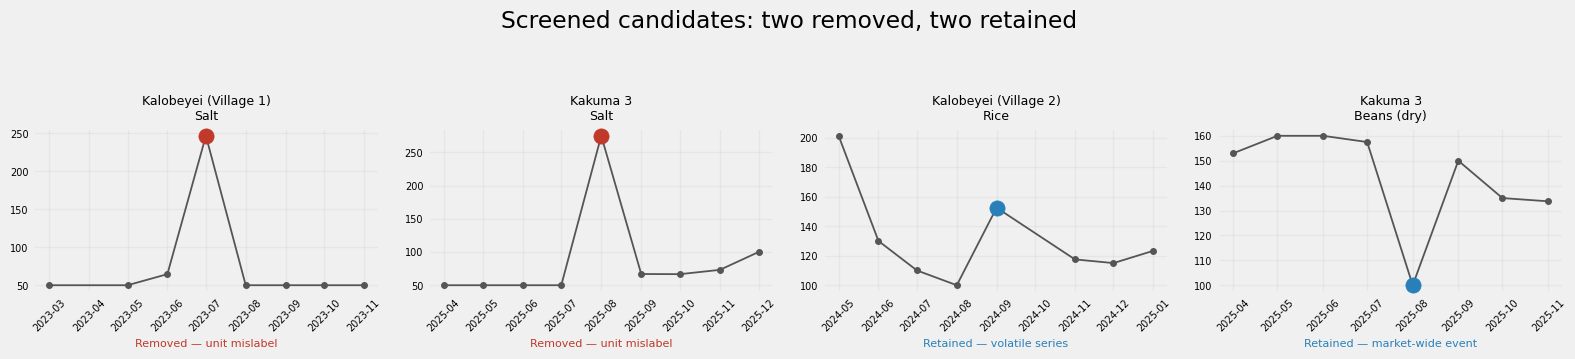

In [ ]:
import matplotlib.pyplot as plt

FIG1 = [("Kalobeyei (Village 1)", "Salt",        "2023-07", "Removed — unit mislabel"),
        ("Kakuma 3",              "Salt",        "2025-08", "Removed — unit mislabel"),
        ("Kalobeyei (Village 2)", "Rice",        "2024-09", "Retained — volatile series"),
        ("Kakuma 3",              "Beans (dry)", "2025-08", "Retained — market-wide event")]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, (mkt, com, m, verdict) in zip(axes, FIG1):
    s = (Bt[(Bt["market"] == mkt) & (Bt["commodity"] == com)]
         .set_index("month")["price_norm"].sort_index())
    p = pd.Period(m, "M")
    w = s.loc[p - 4: p + 4]
    removed = verdict.startswith("Removed")

    ax.plot(w.index.to_timestamp(), w.values, "-o", color="#555", lw=1.3, ms=4)
    ax.scatter([p.to_timestamp()], [s.loc[p]], s=120, zorder=3,
               color="#c0392b" if removed else "#2980b9")
    ax.set_title(f"{mkt}\n{com}", fontsize=9)
    ax.set_xlabel(verdict, fontsize=8,
                  color="#c0392b" if removed else "#2980b9")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(alpha=0.25)

fig.suptitle("Screened candidates: two removed, two retained", y=1.06)
fig.tight_layout()

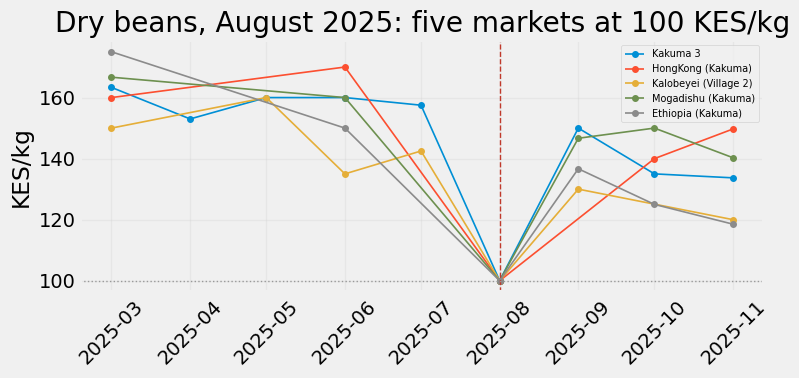

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for mkt in ["Kakuma 3", "HongKong (Kakuma)", "Kalobeyei (Village 2)",
            "Mogadishu (Kakuma)", "Ethiopia (Kakuma)"]:
    s = (Bt[(Bt["market"] == mkt) & (Bt["commodity"] == "Beans (dry)")]
         .set_index("month")["price_norm"].sort_index()
         .loc[pd.Period("2025-03","M"):pd.Period("2025-12","M")])
    ax.plot(s.index.to_timestamp(), s.values, "-o", ms=4, lw=1.2, label=mkt)

ax.axvline(pd.Period("2025-08","M").to_timestamp(), color="#c0392b", ls="--", lw=1)
ax.axhline(100, color="#999", ls=":", lw=1)
ax.set_ylabel("KES/kg"); ax.set_title("Dry beans, August 2025: five markets at 100 KES/kg")
ax.legend(fontsize=7); ax.grid(alpha=0.25)

# Format x-axis to show Year-Month and rotate for better visibility
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

Each flagged observation is examined alongside the surrounding months to determine whether the movement is unusual for that particular series.

The seven-month window helps distinguish three patterns:

- **Isolated spike:** Stable prices before and after the observation suggest a possible recording error.
- **Volatile neighbourhood:** Similar movements in the surrounding months suggest genuine price variation.
- **Persistent level shift:** Prices remain at a different level afterward, suggesting a genuine market event.

###Testing for a Unit Mislabel

In [ ]:
for mkt, com, m in [("Kalobeyei (Village 1)","Salt","2023-07"),
                    ("Kakuma 3","Salt","2025-08"),
                    ("Kakuma 2","Wheat flour","2023-06")]:
    r = Bt[(Bt["market"]==mkt) & (Bt["commodity"]==com) & (Bt["month"]==pd.Period(m,"M"))]
    print(r[["market","commodity","month","price","unit","price_norm"]].to_string(index=False))

               market commodity   month  price  unit  price_norm
Kalobeyei (Village 1)      Salt 2023-07  49.38 200 G       246.9
  market commodity   month  price  unit  price_norm
Kakuma 3      Salt 2025-08   55.0 200 G       275.0
  market   commodity   month  price unit  price_norm
Kakuma 2 Wheat flour 2023-06   55.5   KG        55.5




Three candidates showed an isolated-spike pattern and were investigated using their raw price and unit values.

The two Salt observations had raw prices of 49.38 and 55.00 for 200 G, producing 246.9 and 275.0 KES/kg. Their surrounding prices were around 50 KES/kg, indicating a unit mislabel. Both were therefore set to missing.

Kakuma 2 Wheat flour recorded 55.5 with KG, so the value is internally consistent. Although unusually low, there is no identifiable mechanism for an error, so it was retained.

The rule is therefore simple: remove observations only when there is evidence of how the value went wrong; otherwise retain them.

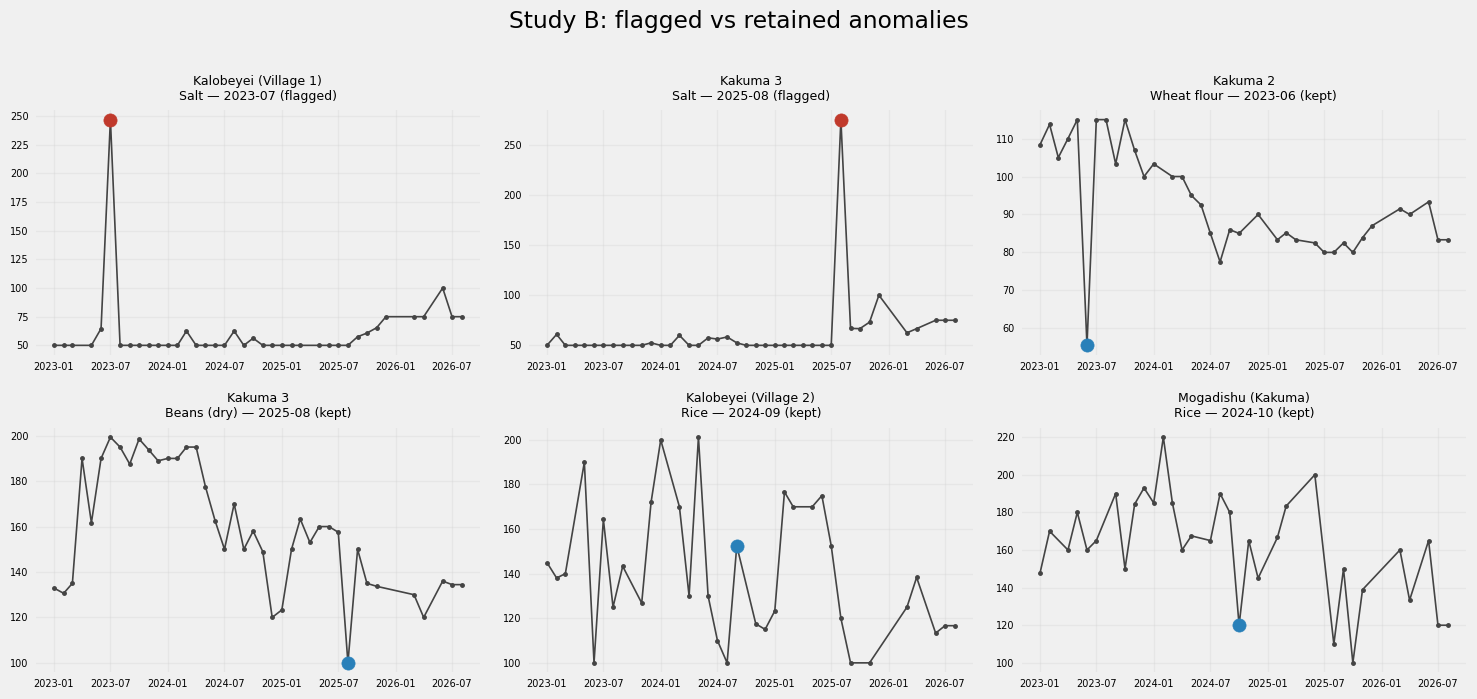

In [ ]:
import matplotlib.pyplot as plt
import os


os.makedirs("figs", exist_ok=True)

CASES = [("Kalobeyei (Village 1)", "Salt", "2023-07", "flagged"),
         ("Kakuma 3", "Salt", "2025-08", "flagged"),
         ("Kakuma 2", "Wheat flour", "2023-06", "kept"),
         ("Kakuma 3", "Beans (dry)", "2025-08", "kept"),
         ("Kalobeyei (Village 2)", "Rice", "2024-09", "kept"),
         ("Mogadishu (Kakuma)", "Rice", "2024-10", "kept")]


raw = Bt.copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=False)
for ax, (mkt, com, m, verdict) in zip(axes.ravel(), CASES):
    s = (raw[(raw["market"] == mkt) & (raw["commodity"] == com)]
         .set_index("month")["price_norm"].sort_index())

    if not s.empty:
        ax.plot(s.index.to_timestamp(), s.values, lw=1.2, color="#444", marker="o", ms=2.5)

        p = pd.Period(m, "M")
        if p in s.index:
            ax.scatter([p.to_timestamp()], [s.loc[p]], s=90, zorder=3,
                       color="#c0392b" if verdict == "flagged" else "#2980b9")

    ax.set_title(f"{mkt}\n{com} — {m} ({verdict})", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

fig.suptitle("Study B: flagged vs retained anomalies", y=1.0)
fig.tight_layout()
plt.savefig("figs/outliers_B.png", dpi=150, bbox_inches="tight")
plt.show()

### Chronological Split

In [ ]:
panel_B = Bt.copy()
VAL_END_B = None   # no fixed validation block; selection by rolling origin inside train

# Is 2026-08 a complete month, or still being reported?
print(panel_B[panel_B["month"] >= "2026-04"].groupby("month").size().to_string())

TRAIN_END_B = pd.Period("2026-01", "M")   # train 2023-01 → 2026-01
                                          # test  2026-02 → 2026-08

cov_B = (panel_B.groupby(["market", "commodity", "pricetype"])
         .agg(n=("month", "size"),
              first=("month", "min"),
              last=("month", "max"),
              train=("month", lambda s: (s <= TRAIN_END_B).sum()),
              test=("month", lambda s: (s > TRAIN_END_B).sum()))
         .reset_index())

assert TRAIN_END_B > panel_B["month"].min(), "train_end precedes the panel"
assert TRAIN_END_B < panel_B["month"].max(), "train_end leaves no test window"

print("\n", cov_B[["train", "test"]].describe().round(1).to_string())
print("\nseries with test < 4:", (cov_B["test"] < 4).sum())
print("series with train < 24:", (cov_B["train"] < 24).sum())
print("\nthinnest by test coverage:")
print(cov_B.nsmallest(8, "test")[["market", "commodity", "train", "test", "last"]].to_string(index=False))

month
2026-04    75
2026-05    21
2026-06    84
2026-07    83
2026-08    68
Freq: M

        train  test
count   84.0  84.0
mean    31.7   5.2
std      3.5   0.8
min     25.0   3.0
25%     28.0   5.0
50%     31.5   5.0
75%     35.0   5.2
max     37.0   7.0

series with test < 4: 2
series with train < 24: 0

thinnest by test coverage:
               market       commodity  train  test    last
             Kakuma 2           Sugar     25     3 2026-06
   Mogadishu (Kakuma)     Wheat flour     25     3 2026-08
             Kakuma 2            Salt     31     4 2026-07
             Kakuma 4           Sugar     27     4 2026-08
Kalobeyei (Village 3)     Beans (dry)     27     4 2026-08
Kalobeyei (Village 3)     Maize flour     26     4 2026-08
Kalobeyei (Village 3) Oil (vegetable)     27     4 2026-08
Kalobeyei (Village 3)            Rice     27     4 2026-08


Forecasting models must be evaluated on **future observations that were not available during training**. The data is therefore divided chronologically rather than randomly. This prevents information from the future from leaking into the training process.

| Block | Period | Purpose |
|---|---|---|
| **Train** | 2023-01 – 2026-01 | Fit models and provide data for rolling-origin model selection |
| **Test** | 2026-02 – 2026-07 | Final evaluation of forecasting accuracy |

The training period contains most of the available history. Rather than setting aside a separate validation block, **model and hyperparameter selection is performed using rolling-origin evaluation within the training period**. This makes better use of Study B's limited history while keeping the final test period completely untouched.

The **test period remains completely untouched until the final evaluation**. No model-selection decision is based on observations from 2026-02 onward.

Forecast accuracy is calculated **separately for each series and then averaged across series**. This prevents series with more observations from receiving greater influence simply because they have fewer gaps.

**Limitation:** Study B has too little history to reliably assess annual seasonality. Rolling-origin evaluation provides repeated forecasting tests across the available history, but it does not replace the longer seasonal evaluation possible in Study A.

## Identifying the Study A(Long historical series) cohort
###Assessing the Study A Cohort

In [ ]:
MIN_MONTHS, MIN_DENSITY = 120, 0.90

cohort = series[(series["n_months"] >= MIN_MONTHS)
                & (series["density"] >= MIN_DENSITY)
                & (series["last_date"] >= "2019-01-01")].copy()

print(f"{len(cohort)} of {(series['n_months'] >= MIN_MONTHS).sum()} long series retained")
print(pd.crosstab(cohort["market"], [cohort["commodity"], cohort["unit"]]))
print(f"\nwindow: {cohort['first_date'].max().date()} → {cohort['last_date'].min().date()}")
print(cohort[["n_months","density"]].describe().round(2).to_string())

22 of 33 long series retained
commodity                  Beans Beans (dry)    Bread Maize Maize (white)     \
unit                          KG       90 KG KG 400 G    KG         90 KG KG   
market                                                                         
Eldoret town (Uasin Gishu)     1           1  0     0     1             1  0   
Kisumu                         1           1  0     0     0             1  0   
Kitui                          0           0  1     0     0             0  1   
Marsabit                       0           0  0     0     0             0  1   
Mombasa                        0           1  0     0     0             1  0   
Nairobi                        0           1  0     1     1             1  0   
Nakuru                         0           0  0     0     1             0  0   

commodity                  Milk (cow, pasteurized) Oil (vegetable)  \
unit                                        500 ML               L   
market                       



Study A draws on the historical programme identified earlier: series with long historical records that largely stopped reporting around 2020. The initial group is narrowed using three criteria designed to ensure that each retained series contains enough reliable information for forecasting.

- **At least 120 months of observations:** Provides sufficient historical depth for estimating temporal patterns and, where supported by the data, investigating seasonality.
- **Density of at least 0.90:** Ensures that at least 90% of the months within a series' observed span contain price observations, reducing the risk that a long nominal history is dominated by missing periods.
- **Ending in 2019 or later:** Ensures that the retained series belong to a broadly comparable historical data-collection period and provide observations close to the end of the Study A forecasting window.

Of the 33 long series identified initially, **22 meet all three criteria**. The retained series have densities above 0.92 and between 156 and 189 months of history, indicating that none is marginal on the minimum history or coverage requirements.

The cohort is then examined at the **market × commodity × price type × unit** level. These dimensions jointly define a forecasting series. This step is important because the same commodity may appear under different labels or units and may represent either a duplicate measurement or a genuinely different price series. Such cases must be investigated before the final panel is constructed.

Coverage is also uneven across markets. Nairobi and Eldoret contribute several commodities, while some markets contribute only one or two. This means that Study A is not a perfectly balanced panel across markets and commodities.

For pooled model evaluation, the **common observation window** is defined by the latest starting date and earliest ending date among the retained series. This ensures that the comparison is conducted over a period for which all selected series have the opportunity to contribute observations.

Overall, Study A forms a **narrow but historically deep forecasting panel**. Its long histories make it suitable for evaluating traditional time-series models and investigating temporal structure, while Study B provides the complementary case of a broader set of current series with substantially shorter histories.

### Testing Whether Paired Commodity Labels Represent the Same Series

In [ ]:
UNIT_KG = {"KG":1.0, "90 KG":90.0, "50 KG":50.0, "400 G":0.4, "L":1.0, "500 ML":0.5}

def get_series(mkt, com, ptype, unit):
    s = df[(df["market"]==mkt) & (df["commodity"]==com)
           & (df["pricetype"]==ptype) & (df["unit"]==unit)].copy()
    s["month"] = s["date"].dt.to_period("M")
    return s.groupby("month")["price"].mean().sort_index() / UNIT_KG[unit]

def compare(mkt, spec_a, spec_b):
    a, b = get_series(mkt, *spec_a), get_series(mkt, *spec_b)
    j = pd.concat([a, b], axis=1, keys=["a","b"]).dropna()
    if len(j) < 12:
        print(f"{mkt:28} {spec_a[0]:14} vs {spec_b[0]:16} overlap={len(j)} — too few")
        return
    ratio = j["a"] / j["b"]
    print(f"{mkt:28} {spec_a[0]:14} vs {spec_b[0]:16} n={len(j):3d}  "
          f"level={j.corr().iloc[0,1]:.3f}  diff={j.diff().dropna().corr().iloc[0,1]:.3f}  "
          f"ratio={ratio.median():.3f}  |%diff|={(ratio-1).abs().median()*100:.1f}%")

PAIRS = [(("Maize","Wholesale","KG"), ("Maize (white)","Wholesale","90 KG")),
         (("Beans","Wholesale","KG"), ("Beans (dry)","Wholesale","90 KG"))]

for spec_a, spec_b in PAIRS:
    both = (set(cohort.loc[(cohort["commodity"]==spec_a[0]) & (cohort["unit"]==spec_a[2]), "market"])
          & set(cohort.loc[(cohort["commodity"]==spec_b[0]) & (cohort["unit"]==spec_b[2]), "market"]))
    for mkt in sorted(both):
        compare(mkt, spec_a, spec_b)
    print()

Eldoret town (Uasin Gishu)   Maize          vs Maize (white)    n=165  level=0.961  diff=0.693  ratio=0.990  |%diff|=4.0%
Nairobi                      Maize          vs Maize (white)    n=169  level=0.954  diff=0.611  ratio=0.983  |%diff|=4.3%

Eldoret town (Uasin Gishu)   Beans          vs Beans (dry)      n=143  level=0.716  diff=0.506  ratio=0.976  |%diff|=23.2%
Kisumu                       Beans          vs Beans (dry)      n=159  level=0.842  diff=0.638  ratio=0.959  |%diff|=7.2%





Some commodities appear under different labels, such as **“Maize” vs “Maize (white)”** and **“Beans” vs “Beans (dry)”**. Before including both in the forecasting panel, the pairs are compared to determine whether they represent the same underlying commodity measurement or meaningfully different products.

Where necessary, both series are first converted to a common **KES/kg** basis. The paired series are then compared using four measures:

- **Level correlation:** Measures how closely the two price levels move together over time.
- **Difference correlation:** Measures how closely their month-to-month price changes move together.
- **Price ratio:** Measures the typical relative level of one series to the other.
- **Median percentage difference:** Measures the typical size of the difference between the two prices.

The **difference correlation is particularly informative** because it removes much of the common long-term price movement and focuses on whether the two series respond similarly from one month to the next. High level correlation alone is not sufficient to establish that two series are duplicates.

The maize pair shows very high level correlations (0.95–0.96), price ratios close to 1, and a median difference of approximately 4%. This indicates that **“Maize” and “Maize (white)” are highly similar measurements of the same underlying market price**, although they are not perfectly identical.

The beans pair shows greater divergence, particularly in Eldoret, where the median difference is approximately 23%. This provides evidence that **“Beans” and “Beans (dry)” may represent different varieties, grades, or market measurements**, rather than simple duplicate records.

Based on these results, **“Maize” is excluded and “Maize (white)” is retained** to avoid giving the same underlying market price disproportionate weight in the forecasting panel. Both Beans labels are retained because the evidence for duplication is weaker.

The approximately **4% difference between the maize series is treated as potential measurement variation rather than assuming the two series are perfectly interchangeable**. The excluded maize series can therefore be retained as a robustness check rather than discarded completely.

### Removing the duplicated maize series

In [ ]:
COHORT = cohort[~((cohort["commodity"] == "Maize") & (cohort["unit"] == "KG"))].copy()
print(len(cohort), "→", len(COHORT))
print(COHORT.groupby("commodity")["market"].nunique().to_string())

22 → 19
commodity
Beans                      2
Beans (dry)                5
Bread                      1
Maize (white)              6
Milk (cow, pasteurized)    1
Oil (vegetable)            1
Potatoes (Irish)           2
Sorghum                    1




Acting on the test above: the "Maize" per-kilogram series is dropped wherever it
appears, leaving "Maize (white)" as the single maize series per market.

The choice between the two is not arbitrary. "Maize (white)" states the grade
explicitly, which matters when the analysis claims to model white maize
specifically, and it is the label carried at markets beyond the two where both
appear — so keeping it preserves a consistent commodity definition across the
panel. The cost is the post-2020 tail that the per-kilogram series holds at
Nairobi and Eldoret, but that period is disrupted and not shared by the rest of
the cohort, so it could not have contributed to a common evaluation window.

The beans pair is left intact, since the test showed those to be distinct
products rather than duplicate recordings.

The final line reports how many markets carry each remaining commodity. This is
what determines whether a commodity can contribute to cross-market pooling: one
present at several markets lets the model learn shared structure, while one
confined to a single market cannot, and is a candidate for exclusion in the next
step.

### Extracting Observations and Normalising Units

In [ ]:
KEYCOLS = ["market_id", "commodity", "pricetype", "unit", "currency"]

A = df.merge(COHORT[KEYCOLS], on=KEYCOLS)
assert len(A) == COHORT["n_obs"].sum(), f"merge changed rows: {len(A)} vs {COHORT['n_obs'].sum()}"

WEIGHT_KG = {"KG": 1.0, "90 KG": 90.0, "50 KG": 50.0, "400 G": 0.4}
VOLUME_L  = {"L": 1.0, "500 ML": 0.5}

A["price_norm"] = np.where(A["unit"].isin(WEIGHT_KG), A["price"] / A["unit"].map(WEIGHT_KG),
                   np.where(A["unit"].isin(VOLUME_L), A["price"] / A["unit"].map(VOLUME_L), np.nan))
A["basis"] = np.where(A["unit"].isin(WEIGHT_KG), "KES/kg",
              np.where(A["unit"].isin(VOLUME_L), "KES/L", None))
A["month"] = A["date"].dt.to_period("M")

print("unresolved units:", A["price_norm"].isna().sum())
print(A["unit"].value_counts().to_string())
print()
print(A.groupby(["commodity", "pricetype", "basis"])["price_norm"]
       .describe()[["count", "min", "50%", "max"]].round(1).to_string())

unresolved units: 0
unit
90 KG     1491
KG         847
50 KG      328
400 G      178
500 ML     178
L          178

                                          count    min    50%    max
commodity               pricetype basis                             
Beans                   Wholesale KES/kg  316.0   29.4   67.1  107.9
Beans (dry)             Retail    KES/kg  180.0   23.0   74.2   98.0
                        Wholesale KES/kg  659.0   21.9   65.3  115.0
Bread                   Retail    KES/kg  178.0   65.0  107.5  130.0
Maize (white)           Retail    KES/kg  351.0    6.0   37.0   62.2
                        Wholesale KES/kg  671.0   10.5   29.3   57.8
Milk (cow, pasteurized) Retail    KES/L   178.0   40.0   86.0  114.0
Oil (vegetable)         Retail    KES/L   178.0  108.0  183.8  250.0
Potatoes (Irish)        Wholesale KES/kg  328.0    9.1   36.6   92.6
Sorghum                 Wholesale KES/kg  161.0   13.6   36.7   57.8




`COHORT` contains one row for each selected forecasting series. The selected series are therefore joined back to the original dataset using the **full series key** to recover all of their underlying price observations.

The full series key consists of:

- `market_id`
- `commodity`
- `pricetype`
- `unit`
- `currency`

Using the complete key is important because a market may report the same commodity under different price types or units. An assertion is then used to confirm that the merge has neither duplicated nor lost observations.

Prices are subsequently converted to a common physical-unit basis:

- **Weight-based commodities:** KES/kg
- **Volume-based commodities:** KES/litre

The two bases are kept separate because a kilogram and a litre measure different physical quantities and therefore cannot be directly compared. Any unrecognised unit produces `NaN`, which must be resolved before the affected observations can be used for modelling.

The normalised prices are then examined by **commodity and price type**. Retail prices are expected to differ from wholesale prices, so these categories are not combined. Price ranges are also reviewed to identify values that may indicate incorrect unit conversion or data-entry errors.

One observation — **retail maize at 6.0 KES/kg** — is substantially below the series median of 37.0 KES/kg and is therefore flagged for individual inspection rather than automatically removed.

Finally, commodities represented in only one market are identified. These commodities are carried forward to the next **coverage assessment**.

### Applying the Coverage Rule

In [ ]:
coverage = A.groupby(["commodity", "basis"])["market"].nunique().sort_values(ascending=False)
print(coverage.to_string())

MIN_MARKETS = 2
keep = coverage.loc[(coverage.index.get_level_values("basis") == "KES/kg")
                    & (coverage >= MIN_MARKETS)].index.get_level_values("commodity")

panel = A[(A["basis"] == "KES/kg") & (A["commodity"].isin(keep))].copy()
panel["log_price"] = np.log(panel["price_norm"])

print(f"\nkept:    {sorted(set(keep))}")
print(f"dropped: {sorted(set(A['commodity']) - set(keep))}")
print(f"\n{panel.groupby(['market','commodity','pricetype']).ngroups} series | {len(panel)} obs")
print(pd.crosstab(panel["market"], [panel["commodity"], panel["pricetype"]]))

commodity                basis 
Maize (white)            KES/kg    6
Beans (dry)              KES/kg    5
Beans                    KES/kg    2
Potatoes (Irish)         KES/kg    2
Bread                    KES/kg    1
Milk (cow, pasteurized)  KES/L     1
Oil (vegetable)          KES/L     1
Sorghum                  KES/kg    1

kept:    ['Beans', 'Beans (dry)', 'Maize (white)', 'Potatoes (Irish)']
dropped: ['Bread', 'Milk (cow, pasteurized)', 'Oil (vegetable)', 'Sorghum']

15 series | 2505 obs
commodity                      Beans Beans (dry)           Maize (white)  \
pricetype                  Wholesale      Retail Wholesale        Retail   
market                                                                     
Eldoret town (Uasin Gishu)       156           0       158             0   
Kisumu                           160           0       164             0   
Kitui                              0         180         0           180   
Marsabit                           0          


Two criteria determine which commodities are included in the Study A pooled panel:

- **Per-kilogram basis only:** Weight-based and volume-based prices cannot be directly combined because they measure different physical quantities. This excludes commodities such as vegetable oil and pasteurised milk from the pooled panel.
- **Presence in at least two markets:** The pooled model is designed to learn patterns that are shared across markets. A commodity therefore needs to be observed in at least two markets to contribute to the pooled panel. This excludes bread and sorghum from the main pooled analysis.

Sorghum is retained separately as a **single-series check** because it has sufficient historical observations for forecasting, even though it does not meet the multi-market requirement. It is therefore not used to train the main pooled panel.

After applying the coverage rule, the main Study A panel contains **15 series, 2,505 observations, six markets, and four commodities**.

The panel represents two distinct market contexts:

- **Commercial wholesale markets:** Maize, beans, and potatoes across Nairobi, Eldoret, Kisumu, and Mombasa.
- **Arid-county retail markets:** Maize and beans across Kitui and Marsabit.

These market contexts operate under different pricing conditions. **Market type is therefore retained as a model feature**, rather than assuming that all markets are interchangeable.

The retained series contain between **156 and 180 observations**, providing broadly comparable historical depth across the panel. This makes the resulting dataset suitable for comparing per-series time-series models with a pooled forecasting approach.

### Screening for Recording Errors

In [ ]:
panel = panel.sort_values("month")
g = panel.groupby(["market", "commodity", "pricetype"])["price_norm"]
panel["lr"] = np.log(panel["price_norm"]) - np.log(g.shift(1))
panel["lr_next"] = -panel.groupby(["market", "commodity", "pricetype"])["lr"].shift(-1)

susp = panel[(panel["lr"].abs() > 0.35) & (panel["lr"] * panel["lr_next"] > 0.6 * panel["lr"]**2)]
print(f"{len(susp)} flagged of {len(panel)}")
print(susp[["market", "commodity", "pricetype", "month", "price_norm", "lr"]].to_string(index=False))

6 flagged of 2505
 market        commodity pricetype   month  price_norm        lr
  Kitui    Maize (white)    Retail 2010-06    6.000000 -0.773190
Mombasa      Beans (dry) Wholesale 2013-01   28.900000 -0.652141
 Kisumu Potatoes (Irish) Wholesale 2015-07   23.939200 -0.418051
Nairobi Potatoes (Irish) Wholesale 2015-07   13.787600 -0.524684
Mombasa      Beans (dry) Wholesale 2019-01   36.533333 -0.385256
Nairobi Potatoes (Irish) Wholesale 2019-05   76.800000  0.399623




Large month-to-month price movements do not automatically indicate data errors. A sharp increase may represent a genuine market shock, while a recording error may appear as a sudden increase that is immediately reversed the following month. The screening rule therefore looks for the **shape of the movement**, not just its size.

The screen uses three conditions:

- `lr` measures the **monthly log price change**. A threshold of `|lr| > 0.35` identifies relatively large month-to-month movements that require inspection.
- `lr_next` reverses the sign of the following month's return. This makes an opposite movement positive, allowing the next month's movement to be compared with the original change.
- `lr × lr_next > 0.6 × lr²` requires the following month's movement to reverse at least **60% of the original movement**.

For example, if a price suddenly rises by a large amount and then falls by most of that amount the following month, the observation is flagged. In contrast, a large increase followed by another increase is not flagged because there is no immediate reversal.

Log returns are used because they express price movements in relative terms and treat increases and decreases more symmetrically than absolute price changes.

The calculation is performed separately within each **market × commodity × pricetype** series. This is important because returns must be calculated between consecutive observations belonging to the same forecasting series. Without this grouping, a wholesale observation could incorrectly be compared with a retail observation.

The screen is intentionally designed as a **candidate-generation rule, not an automatic error-removal rule**. A flagged observation is therefore inspected against the surrounding months and the original record before being classified as a recording error or retained as a genuine price movement.

The screen flags **6 of 2,505 observations (0.24%)**. These observations are carried forward for individual inspection rather than automatically removed from the dataset.

### Inspecting Each Candidate in Context

In [ ]:
for _, r in susp.iterrows():
    s = (panel[(panel["market"] == r["market"])
             & (panel["commodity"] == r["commodity"])
             & (panel["pricetype"] == r["pricetype"])]
         .set_index("month")["price_norm"])
    w = s.loc[r["month"] - 3 : r["month"] + 3]
    print(f"\n{r['market']} | {r['commodity']} ({r['pricetype']}) | {r['month']}")
    print("  " + "  ".join(f"{i}:{v:.1f}" for i, v in w.items()))


Kitui | Maize (white) (Retail) | 2010-06
  2010-03:16.0  2010-04:13.0  2010-05:13.0  2010-06:6.0  2010-07:15.0  2010-08:13.0  2010-09:13.0

Mombasa | Beans (dry) (Wholesale) | 2013-01
  2012-10:61.8  2012-11:53.7  2012-12:55.5  2013-01:28.9  2013-02:51.3  2013-03:60.6  2013-04:67.2

Kisumu | Potatoes (Irish) (Wholesale) | 2015-07
  2015-04:37.9  2015-05:44.4  2015-06:36.4  2015-07:23.9  2015-08:42.0  2015-09:55.5  2015-10:70.1

Nairobi | Potatoes (Irish) (Wholesale) | 2015-07
  2015-04:28.5  2015-05:29.1  2015-06:23.3  2015-07:13.8  2015-08:34.0  2015-09:48.4  2015-10:54.6

Mombasa | Beans (dry) (Wholesale) | 2019-01
  2018-10:58.3  2018-11:56.3  2018-12:53.7  2019-01:36.5  2019-02:69.2  2019-03:67.3  2019-04:63.8

Nairobi | Potatoes (Irish) (Wholesale) | 2019-05
  2019-02:41.4  2019-03:45.0  2019-04:51.5  2019-05:76.8  2019-06:55.9  2019-07:50.6  2019-08:30.4




The screening rule identifies **candidates for inspection, not confirmed recording errors**. Each flagged observation is therefore examined within a seven-month window — three months before the flagged month, the flagged month itself, and three months after it. This provides enough surrounding context to determine whether the unusual movement is isolated or part of a broader price pattern.

The surrounding windows help distinguish three main patterns:

- **Isolated spike:** The price changes sharply in the flagged month but returns to approximately its previous level afterward. This pattern is consistent with a possible recording error.
- **Gradual rise and fall:** The price changes over several consecutive months rather than jumping and immediately reversing. This suggests a genuine market movement rather than a single erroneous observation.
- **Synchronised movement:** Similar price movements occur across other markets during the same period. This provides additional evidence that the change may reflect a broader market event rather than a recording error.

The inspection retains **`market`, `commodity`, and `pricetype`** when constructing each window. This ensures that retail and wholesale observations remain separate and that each candidate is evaluated against the correct forecasting series.

All six flagged candidates are displayed for inspection, including observations that are ultimately retained as valid prices. This makes the cleaning process **transparent and reproducible**: every candidate identified by the screening rule can be traced to the final decision rather than being silently removed.

### Distinguishing Anomaly from Seasonality

In [ ]:
mb = panel[(panel["market"]=="Mombasa") & (panel["commodity"]=="Beans (dry)")]
print(mb.groupby(mb["month"].dt.month)["lr"].median().round(3).to_string())

month
1     0.053
2     0.046
3     0.043
4     0.021
5     0.011
6    -0.120
7    -0.009
8     0.021
9     0.039
10    0.004
11   -0.038
12   -0.036




Two flagged observations occur in **Mombasa wholesale beans**, specifically in January 2013 and January 2019. Because both observations occur in the same calendar month, their unusual downward movements could potentially reflect a recurring seasonal pattern rather than recording errors.

To investigate this possibility, the typical log return for each calendar month is calculated across the full series. The **median monthly return** is used because it is less sensitive to extreme observations than the mean.

The results show that **January normally has a positive median return (+0.053)**, indicating that prices typically increase rather than decrease during this month. The two large January declines therefore do not follow the usual seasonal pattern, providing additional evidence that these observations are anomalous rather than normal seasonal movements.

As a further check, **June has the strongest negative median return (−0.120)**, indicating that meaningful seasonal price declines do occur in the series. These genuine seasonal movements are retained because they represent recurring market behaviour rather than data-quality problems.

Seasonality is therefore used as **supporting evidence during anomaly inspection**, rather than as an automatic rule for removing observations.

### Recording the Flagged Observations

In [ ]:
FLAGGED_A = [
    ("Kitui",   "Maize (white)", "Retail",    "2010-06", "isolated_v_suspected_error"),
    ("Mombasa", "Beans (dry)",   "Wholesale", "2013-01", "isolated_v_suspected_error"),
    ("Mombasa", "Beans (dry)",   "Wholesale", "2019-01", "isolated_v_suspected_error"),
]

panel_A = panel.copy()
panel_A["flag_outlier"] = None

for mkt, com, pt, m, reason in FLAGGED_A:
    mask = ((panel_A["market"] == mkt) & (panel_A["commodity"] == com)
            & (panel_A["pricetype"] == pt) & (panel_A["month"] == pd.Period(m, "M")))
    assert mask.sum() == 1, f"expected 1 row, got {mask.sum()} for {mkt}/{com}/{m}"
    panel_A.loc[mask, ["flag_outlier", "price_norm", "log_price"]] = [reason, np.nan, np.nan]

print(panel_A["flag_outlier"].value_counts(dropna=False))
print(f"{panel_A.groupby(['market','commodity','pricetype']).ngroups} series | {len(panel_A)} obs")

flag_outlier
None                          2502
isolated_v_suspected_error       3
Name: count, dtype: int64
15 series | 2505 obs




Of the six observations identified by the anomaly screen, **three are classified as recording errors after contextual inspection**:

- **Kitui retail maize — 2010-06**
- **Mombasa wholesale beans — 2013-01**
- **Mombasa wholesale beans — 2019-01**

The remaining three flagged observations are retained because their movements are consistent with genuine market behaviour.

For the three confirmed errors, the affected price values are set to **`NaN` rather than deleting the rows**. This preserves the observation's market, commodity, price type, and calendar position while indicating that the recorded price should not be used as a valid numerical value.

Both **`price_norm`** and **`log_price`** are set to `NaN` so that the derived variables remain consistent with the corrected price observation.

An assertion is used when identifying each flagged observation to ensure that every specified combination of **market, commodity, price type, and month** matches exactly one observation. This prevents an incorrect or incomplete match from silently modifying the wrong record or leaving the suspected error unchanged.

After cleaning, **3 of the 2,505 observations (0.12%)** are set to missing. The other three flagged candidates remain in the dataset because their movements were judged to be consistent with genuine market behaviour.

This approach preserves the full audit trail: the original observations remain identifiable, the suspected errors are explicitly marked as missing, and the retained candidates demonstrate that the anomaly screen was used for **inspection and evidence-based classification rather than automatic deletion**.

### Chronological Split

In [ ]:
TRAIN_END_A = pd.Period("2015-12", "M")
VAL_END_A   = pd.Period("2017-12", "M")

cov_A = (panel_A.groupby(["market", "commodity", "pricetype"])
         .agg(n=("month", "size"), first=("month", "min"), last=("month", "max"),
              train=("month", lambda s: (s <= TRAIN_END_A).sum()),
              val=("month", lambda s: ((s > TRAIN_END_A) & (s <= VAL_END_A)).sum()),
              test=("month", lambda s: (s > VAL_END_A).sum()))
         .reset_index())

assert cov_A["train"].min() >= 100, "a series has too little training history"
assert cov_A["test"].min() >= 5, "a series has too few test months"

print(cov_A.sort_values("test").to_string(index=False))
print("\n", cov_A[["train", "val", "test"]].describe().round(1).to_string())

                    market        commodity pricetype   n   first    last  train  val  test
Eldoret town (Uasin Gishu)            Beans Wholesale 156 2006-01 2019-07    113   24    19
                    Kisumu            Beans Wholesale 160 2006-01 2019-07    117   24    19
                    Kisumu    Maize (white) Wholesale 164 2006-01 2019-10    119   23    22
                    Kisumu      Beans (dry) Wholesale 164 2006-01 2019-10    119   23    22
                    Kisumu Potatoes (Irish) Wholesale 161 2006-01 2019-10    116   23    22
Eldoret town (Uasin Gishu)      Beans (dry) Wholesale 158 2006-01 2020-03    113   22    23
                   Mombasa      Beans (dry) Wholesale 167 2006-01 2020-03    119   23    25
                   Mombasa    Maize (white) Wholesale 167 2006-01 2020-03    119   23    25
                   Nairobi Potatoes (Irish) Wholesale 167 2006-01 2020-03    117   23    27
Eldoret town (Uasin Gishu)    Maize (white) Wholesale 170 2006-01 2020-03    119



Forecasts must be evaluated on **future observations that were not available to the model during training**. The data is therefore divided chronologically rather than randomly. This prevents information from the future from leaking into model training or model selection.

| Block | Period | Purpose |
|---|---|---|
| **Train** | 2006-01 – 2015-12 | Fit the forecasting models |
| **Validation** | 2016-01 – 2017-12 | Select models and tune hyperparameters |
| **Test** | 2018-01 onward | Final evaluation of forecasting performance |

The **24-month validation period** covers two complete annual cycles. This provides a reasonable basis for selecting models that account for recurring seasonal patterns, while the training period provides approximately ten years of historical observations for estimating longer-term behaviour and annual seasonality.

All **15 selected series are represented across the three time blocks**, although individual missing months mean that the exact number of observations varies between series. The test period therefore differs in length across series, ranging from **19 to 36 months**, because some markets and commodities stop reporting earlier than others.

Because test periods contain different numbers of observations, forecast accuracy is calculated **separately for each series and then averaged across the 15 series**. This gives each forecasting series equal weight rather than allowing longer series to dominate the overall result.

The test period includes observations from **2018 through 2020**, providing a challenging evaluation period that includes major market disruptions. These include the effects of the **2017 drought and maize subsidy programme**, as well as the onset of **COVID-19 in 2020**. These events provide useful context for assessing whether the forecasting models remain robust when market conditions change substantially.

The test observations remain **untouched during model selection** and are used only after the final modelling decisions have been made.

In [ ]:
# indicating covid era
panel_A["covid_era"] = panel_A["month"] >= pd.Period("2020-03", "M")

---

## 5. Recording the Study B Anomalies

The Study B screen identified 21 candidate observations, which were inspected in context
and tested for unit mislabelling above. Two are confirmed recording errors and are
recorded here.

Both are salt prices whose raw values (49.38 and 55.00) are plausible **per-kilogram**
figures but were recorded against a 200 g unit, converting to 246.9 and 275.0 KES/kg
against a series otherwise flat at 50 KES/kg. The mechanism is identifiable, which is the
standard applied throughout: an observation is removed only when it can be said *how* it
went wrong.

The Kakuma 2 wheat flour observation is retained. It is roughly half its neighbours, but
`price` and `unit` are internally consistent and no mechanism can be identified. The five
dry-bean observations of August 2025 are also retained: five independently monitored
markets recording exactly 100.00 KES/kg in the same month, each recovering to a level
below where it started, indicates a market-wide event rather than five coincident errors.

Values are set to `NaN` rather than deleted, preserving the calendar position so that the
gap is handled by the model rather than silently filled.

In [ ]:
FLAGGED_B = [
    ("Kalobeyei (Village 1)", "Salt", "2023-07", "unit_mislabel_200g"),
    ("Kakuma 3",              "Salt", "2025-08", "unit_mislabel_200g"),
]

panel_B = Bt.copy()
panel_B["flag_outlier"] = None

for mkt, com, m, reason in FLAGGED_B:
    mask = ((panel_B["market"] == mkt) & (panel_B["commodity"] == com)
            & (panel_B["month"] == pd.Period(m, "M")))
    assert mask.sum() == 1, f"expected 1 row, got {mask.sum()} for {mkt}/{com}/{m}"
    panel_B.loc[mask, ["flag_outlier", "price_norm", "log_price"]] = [reason, np.nan, np.nan]

print(panel_B["flag_outlier"].value_counts(dropna=False).to_string())
print(f"\nStudy B panel: {panel_B.groupby(['market','commodity','pricetype']).ngroups} series | "
      f"{len(panel_B)} observations")
print(f"Study A panel: {panel_A.groupby(['market','commodity','pricetype']).ngroups} series | "
      f"{len(panel_A)} observations")

flag_outlier
None                  3092
unit_mislabel_200g       2

Study B panel: 84 series | 3094 observations
Study A panel: 15 series | 2505 observations


---

# 6. Modelling Strategy

## Why These Models Were Selected

Four models are fitted, forming a ladder in which each rung tests one additional idea.
None is included to increase the count of algorithms; each answers a question the
previous rung leaves open.

### Naive — the benchmark

The forecast for next month is this month's price. This is not a placeholder. Every
series in Study A was shown to be **I(1)** — non-stationary in levels, stationary in first
differences, with ADF and KPSS agreeing on all 15 series. For a random walk, the naive
forecast is the theoretically optimal one-step prediction. Any model that fails to beat
it has demonstrated that the series carries no exploitable structure beyond its own last
value, which is a legitimate result rather than a failure of the analysis.

### Seasonal naive — testing seasonal persistence

The forecast is the price twelve months earlier. Applied to Study A only; Study B's
40-month window leaves too few usable comparisons. Kenya's bimodal rainfall and its
maize marketing calendar give a physical reason to expect annual structure, so this is
worth testing directly rather than assuming.

### ARIMA / SARIMA — temporal structure

ARIMA models the autocorrelation in the series itself: how strongly the current value
depends on recent values and recent errors. It is fitted **per series**, so it can only
use that series' own history.

Two things justify it here beyond convention. First, the order of integration selected is
itself a result — it tells you whether prices are trend-reverting or random-walk-like, and
that constrains what *any* model can achieve. Second, it provides a principled, per-series
benchmark against which the pooled model's advantage can be measured. Differencing order
is fixed at `d = 1` on the evidence of the stationarity tests; the remaining orders are
selected by AICc on training data only.

### XGBoost — pooling and conditioning

The weak justification for gradient boosting is that it captures non-linearity. The
justification that matters here is structural:

1. **Pooling.** ARIMA fits each series in isolation. XGBoost is fitted **once across the
   entire panel**, with market and commodity as features, so a sparse or short series
   benefits from patterns learned in well-covered ones. This is a capability ARIMA does
   not have, and it is directly testable.
2. **Conditioning at scale.** A per-series model with 40 observations overfits beyond a
   handful of predictors. A pooled model trained on thousands of rows can use a dozen
   covariates — cross-market prices, rolling volatility, deviation from a trailing mean —
   without the same penalty.
3. **Interactions.** The effect of a price deviation plausibly depends on the commodity,
   the market type and the season. Trees find such interactions without them being
   specified in advance.

### The comparison this sets up

Study A has long history and few series; Study B has short history and many. If pooling
substitutes for history, XGBoost should gain most in Study B, where per-series models
have least to work with. That contrast is the analytical core of the project, and it is
why both studies are carried through rather than only the stronger one.

### Deep learning was considered and rejected

LSTM and GRU models are common in price-forecasting work. They are not appropriate here.
Study A offers roughly 120 training months per series and Study B roughly 30. Recurrent
networks require orders of magnitude more data to estimate their parameters stably, and
on samples this size they would overfit and produce results that could not be
distinguished from noise. Using them because they are popular, rather than because the
data supports them, would be the clearest possible instance of choosing a model before
choosing a problem.

## 6.1 Shared Evaluation Utilities

All models are scored through the same functions so that no difference in results can
come from differences in how they were measured.

**`build_matrix`** reshapes a panel into one column per series indexed by calendar month,
with missing months present as `NaN`. This matters more than it appears: without an
explicit monthly index, a lag of one row could span a two-month gap, and `lag1` would mean
different things in different parts of the same series.

**`eligible_series`** fixes the list of series every model is scored on. A series
qualifies only if it has enough training history and enough test months whose immediate
predecessor is also observed — the naive benchmark cannot be computed across a gap.
Fixing this set in advance is essential: a model that silently skipped the harder series
would appear to outperform one that did not.

**`mase`** — Mean Absolute Scaled Error — divides each series' test error by the mean
absolute month-to-month change within its own training period. This makes series at
different price levels comparable and lets each contribute equally to a summary
regardless of how many test months it happens to have. `MAE` and `RMSE` in KES per
kilogram are reported alongside, because they are readable in the units a decision-maker
uses and remain well-behaved where MASE does not.

**One caveat carried through the whole evaluation.** MASE below 1.0 does not mean a model
beat the naive forecast; the naive forecast supplies the *denominator*, computed in
sample. A value below 1 means the test period was calmer than the training period.
Models must therefore be compared against each other, not against 1.0.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

def build_matrix(panel, extend_to=None):
    """One column per series, indexed by month, with gaps present as NaN.

    `extend_to` appends empty future months, which the recursive forecaster needs
    so that features can be built for a month that has no observation yet.
    """
    m = panel.pivot_table(index="month",
                          columns=["market", "commodity", "pricetype"],
                          values="log_price", aggfunc="first")
    end = m.index.max() if extend_to is None else max(m.index.max(), extend_to)
    return m.reindex(pd.period_range(m.index.min(), end, freq="M"))


def eligible_series(panel, train_end, min_train=24, min_test=3):
    """Series scoreable by every model, fixed once so the comparison is like-for-like."""
    M = build_matrix(panel)
    cols = []
    for c in M.columns:
        s = M[c]
        te = s[s.index > train_end]
        scoreable = (te.notna() & s.shift(1).reindex(te.index).notna()).sum()
        if s[s.index <= train_end].notna().sum() >= min_train and scoreable >= min_test:
            cols.append(c)
    return cols


def mase(y_true, y_pred, y_train):
    """Error scaled by the in-sample naive error of the same series."""
    d = np.abs(np.diff(y_train[~np.isnan(y_train)])).mean()
    return np.nanmean(np.abs(y_true - y_pred)) / d


def score(col, te_log, pred_log, tr_log, model):
    """Score one series. Errors are computed in KES/kg; MASE on the log scale."""
    ok = te_log.notna() & pred_log.notna()
    if ok.sum() < 3:
        return None
    yt, yp = np.exp(te_log[ok]), np.exp(pred_log[ok])
    return {"market": col[0], "commodity": col[1], "pricetype": col[2], "model": model,
            "n": int(ok.sum()),
            "mae": float(np.mean(np.abs(yt - yp))),
            "rmse": float(np.sqrt(np.mean((yt - yp) ** 2))),
            "mase": float(mase(te_log[ok].values, pred_log[ok].values, tr_log.values)),
            "errors": (yt - yp).values,
            "months": te_log[ok].index}


COLS_A = eligible_series(panel_A, TRAIN_END_A, min_train=60, min_test=3)
COLS_B = eligible_series(panel_B, TRAIN_END_B, min_train=18, min_test=3)

nA, nB = build_matrix(panel_A).shape[1], build_matrix(panel_B).shape[1]
print(f"Study A: {len(COLS_A)} of {nA} series eligible")
print(f"Study B: {len(COLS_B)} of {nB} series eligible")

dropped_B = [c for c in build_matrix(panel_B).columns if c not in COLS_B]
if dropped_B:
    print(f"\nStudy B exclusions ({len(dropped_B)}) — too few consecutive test pairs:")
    for c in dropped_B:
        print("   ", " | ".join(map(str, c)))

Study A: 15 of 15 series eligible
Study B: 73 of 84 series eligible

Study B exclusions (11) — too few consecutive test pairs:
    Kakuma 2 | Salt | Retail
    Kakuma 2 | Sugar | Retail
    Kakuma 4 | Sugar | Retail
    Kalobeyei (Village 3) | Beans (dry) | Retail
    Kalobeyei (Village 3) | Maize flour | Retail
    Kalobeyei (Village 3) | Oil (vegetable) | Retail
    Kalobeyei (Village 3) | Rice | Retail
    Kalobeyei (Village 3) | Salt | Retail
    Kalobeyei (Village 3) | Sugar | Retail
    Kalobeyei (Village 3) | Wheat flour | Retail
    Mogadishu (Kakuma) | Wheat flour | Retail


## 6.2 Baseline Forecasts

Nothing that follows is interpretable until the bar is known. Both baselines are computed
on the fixed eligible set.

In [ ]:
def baselines(panel, train_end, cols, seasonal=True):
    M = build_matrix(panel)
    rows = []
    for c in cols:
        s = M[c]
        tr, te = s[s.index <= train_end], s[s.index > train_end]
        preds = {"Naive": s.shift(1).reindex(te.index)}
        if seasonal:
            preds["Seasonal naive"] = s.shift(12).reindex(te.index)
        for name, pred in preds.items():
            r = score(c, te, pred, tr, name)
            if r:
                rows.append(r)
    return pd.DataFrame(rows)


base_A = baselines(panel_A, TRAIN_END_A, COLS_A, seasonal=True)
base_B = baselines(panel_B, TRAIN_END_B, COLS_B, seasonal=False)

for tag, b in [("A", base_A), ("B", base_B)]:
    print(f"\n--- Study {tag} ---")
    print(b.groupby("model")[["mase", "mae", "rmse"]].agg(["median", "mean"]).round(3).to_string())
    print(b.groupby("model").apply(
        lambda g: pd.Series({"n_series": len(g), "below_own_naive_scale": int((g["mase"] < 1).sum())}),
        include_groups=False).to_string())


--- Study A ---
                 mase            mae            rmse        
               median   mean  median    mean  median    mean
model                                                       
Naive           0.890  0.856   3.746   3.792   5.473   5.224
Seasonal naive  2.595  3.010  10.706  12.195  13.377  14.705
                n_series  below_own_naive_scale
model                                          
Naive                 15                     11
Seasonal naive        15                      0

--- Study B ---
        mase           mae          rmse       
      median   mean median   mean median   mean
model                                          
Naive  0.547  1.025  5.553  6.951  6.738  9.341
       n_series  below_own_naive_scale
model                                 
Naive        73                     60


### Reading the Baselines

Two results are already established at this point.

**Seasonal persistence is absent in Study A.** Seasonal naive is roughly three times worse
than naive and beats it on no series at all. The price level twelve months earlier carries
no usable information about the current level. This is consistent with two earlier
findings — every series is I(1), and STL seasonal strength peaks at about 0.37, describing
a pattern in the *detrended* series rather than one strong enough to forecast levels from.
Seasonal differencing is therefore not expected to help, and the ARIMA search below is
left free to select `D = 0`.

**Study B's mean and median diverge sharply**, and the median is the honest summary. Two
salt series, at Hagadera and Dagahaley, return very large MASE values. Their prices held
at exactly 50.0 KES/kg for 34 consecutive training months before moving in the final two,
so the in-sample naive error scaling the metric is close to zero and any test-period
movement divides by it. Their MAE in KES/kg is unremarkable beside the other series.

Those two series are retained. A regime change from an administered price to a moving one
is a genuine forecasting failure mode, and removing the hard cases because they are hard
would bias the evaluation. They are the clearest illustration in this data of why
prediction intervals matter more than point forecasts.

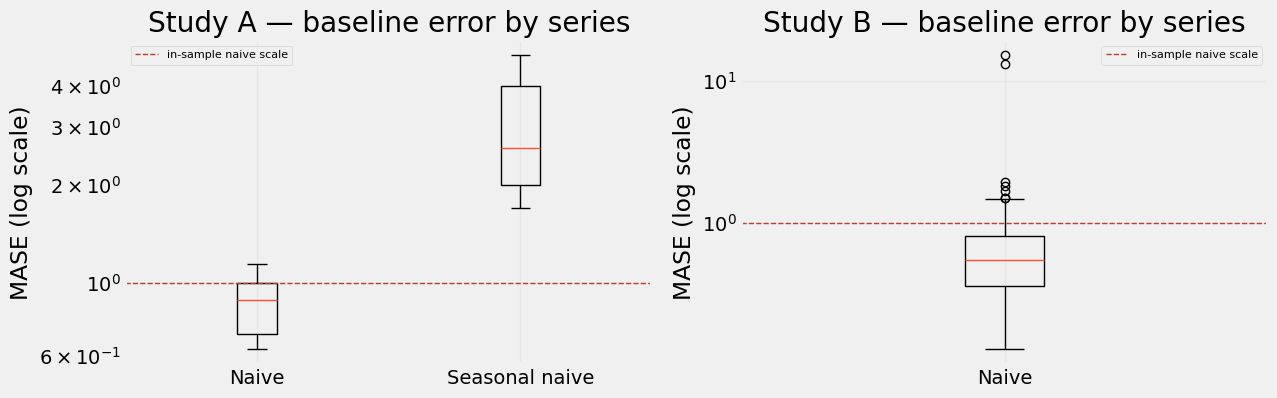

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, (tag, b) in zip(axes, [("A", base_A), ("B", base_B)]):
    data = [b.loc[b["model"] == m, "mase"].values for m in b["model"].unique()]
    ax.boxplot(data, labels=b["model"].unique(), showfliers=True)
    ax.axhline(1.0, color="#c0392b", ls="--", lw=1, label="in-sample naive scale")
    ax.set_yscale("log")
    ax.set_ylabel("MASE (log scale)")
    ax.set_title(f"Study {tag} — baseline error by series")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6.3 ARIMA / SARIMA

Fitted **per series**, so each model sees only its own history.

**Order selection.** Differencing is fixed at `d = 1` on the evidence of the ADF and KPSS
tests, which agreed on all 15 Study A series. The remaining orders are chosen by
corrected AIC over a small grid, computed **on training data only**. Using AICc rather
than AIC matters at these sample sizes: with roughly 120 observations and up to six
parameters, the small-sample correction is not negligible. Selecting orders on the full
series and then reporting out-of-sample error on part of it would be model-selection
leakage, which is why the search is confined to the training block.

**Seasonal terms** are searched for Study A only, and the search includes `D = 0` so the
data can decline them — which, given the seasonal-naive result, is the expected outcome.
Study B's 40-month window cannot support a 12-month seasonal cycle at all.

**Forecasting.** Parameters are estimated on the training block, then applied to the full
series so that one-step-ahead predictions can be generated across the test period without
re-estimating on test data. Missing months are handled by the Kalman filter, which
marginalises over them properly rather than requiring imputed values.

This cell fits a model per series across a small grid and takes a few minutes.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def _aicc(res):
    k, n = res.params.size, res.nobs
    return res.aic + (2 * k * (k + 1)) / max(n - k - 1, 1)


def pick_order(y, seasonal):
    """Select (p,d,q)(P,D,Q,12) by AICc on training data only. d fixed at 1."""
    best = (np.inf, None)
    orders = [(p, 1, q) for p in range(3) for q in range(3)]
    sorders = [(0, 0, 0, 0)]
    if seasonal:
        sorders += [(P, D, Q, 12) for P in (0, 1) for D in (0, 1) for Q in (0, 1)
                    if (P, D, Q) != (0, 0, 0)]
    for o in orders:
        for so in sorders:
            try:
                res = SARIMAX(y, order=o, seasonal_order=so,
                              enforce_stationarity=False,
                              enforce_invertibility=False).fit(disp=False)
                v = _aicc(res)
                if np.isfinite(v) and v < best[0]:
                    best = (v, (o, so))
            except Exception:
                continue
    return best[1] or ((1, 1, 0), (0, 0, 0, 0))


def fit_arima(panel, train_end, cols, seasonal=True, verbose=False):
    M = build_matrix(panel)
    rows, chosen, resid = [], {}, {}
    for c in cols:
        s = M[c].astype(float)
        tr, te = s[s.index <= train_end], s[s.index > train_end]
        try:
            o, so = pick_order(tr, seasonal)
            trained = SARIMAX(tr, order=o, seasonal_order=so,
                              enforce_stationarity=False,
                              enforce_invertibility=False).fit(disp=False)
            full = SARIMAX(s, order=o, seasonal_order=so,
                           enforce_stationarity=False,
                           enforce_invertibility=False).filter(trained.params)
            pred = full.get_prediction(start=te.index[0]).predicted_mean
            pred = pd.Series(np.asarray(pred), index=te.index[:len(pred)])
            chosen[c] = (o, so)
            resid[c] = trained.resid
            r = score(c, te, pred.reindex(te.index), tr, "ARIMA")
            if r:
                rows.append(r)
            if verbose:
                print(f"  {c[0][:18]:18} {c[1][:14]:14} {o} {so}")
        except Exception as e:
            print(f"  FAILED {c}: {e}")
    return pd.DataFrame(rows), chosen, resid


print("Study A — fitting SARIMA per series ...")
arima_A, orders_A, resid_A = fit_arima(panel_A, TRAIN_END_A, COLS_A, seasonal=True, verbose=True)

print("\nStudy B — fitting ARIMA per series ...")
arima_B, orders_B, resid_B = fit_arima(panel_B, TRAIN_END_B, COLS_B, seasonal=False)

print("\nSelected orders, Study A:")
print(pd.Series({f"{k[0][:16]} | {k[1][:12]}": f"{v[0]}{v[1]}" for k, v in orders_A.items()}).to_string())
print("\nSeasonal terms selected in Study A:",
      sum(1 for v in orders_A.values() if v[1] != (0, 0, 0, 0)), "of", len(orders_A))

Study A — fitting SARIMA per series ...
  Eldoret town (Uasi Beans          (1, 1, 1) (0, 0, 0, 0)
  Eldoret town (Uasi Beans (dry)    (0, 1, 1) (1, 0, 0, 12)
  Eldoret town (Uasi Maize (white)  (1, 1, 0) (0, 0, 0, 0)
  Kisumu             Beans          (1, 1, 1) (0, 0, 0, 0)
  Kisumu             Beans (dry)    (2, 1, 1) (0, 0, 0, 0)
  Kisumu             Maize (white)  (1, 1, 0) (0, 0, 0, 0)
  Kisumu             Potatoes (Iris (2, 1, 2) (0, 0, 0, 0)
  Kitui              Beans (dry)    (2, 1, 2) (0, 0, 0, 0)
  Kitui              Maize (white)  (0, 1, 2) (0, 0, 1, 12)
  Marsabit           Maize (white)  (2, 1, 2) (0, 0, 0, 0)
  Mombasa            Beans (dry)    (2, 1, 2) (0, 0, 0, 0)
  Mombasa            Maize (white)  (0, 1, 0) (0, 0, 0, 0)
  Nairobi            Beans (dry)    (2, 1, 2) (0, 0, 0, 0)
  Nairobi            Maize (white)  (1, 1, 0) (0, 0, 0, 0)
  Nairobi            Potatoes (Iris (2, 1, 2) (0, 0, 0, 0)

Study B — fitting ARIMA per series ...

Selected orders, Study A:
Eldore

In [ ]:
from collections import Counter
print("Study A orders:", Counter(str(v[0]) for v in orders_A.values()))
print("Study B orders:", Counter(str(v[0]) for v in orders_B.values()))
print("Study A seasonal:", Counter(str(v[1]) for v in orders_A.values()))

Study A orders: Counter({'(2, 1, 2)': 6, '(1, 1, 0)': 3, '(1, 1, 1)': 2, '(0, 1, 1)': 1, '(2, 1, 1)': 1, '(0, 1, 2)': 1, '(0, 1, 0)': 1})
Study B orders: Counter({'(1, 1, 0)': 25, '(0, 1, 1)': 19, '(0, 1, 0)': 12, '(2, 1, 0)': 5, '(0, 1, 2)': 4, '(1, 1, 1)': 3, '(2, 1, 1)': 2, '(1, 1, 2)': 2, '(2, 1, 2)': 1})
Study A seasonal: Counter({'(0, 0, 0, 0)': 13, '(1, 0, 0, 12)': 1, '(0, 0, 1, 12)': 1})


### Residual Diagnostics

A forecast model's residuals should contain no remaining structure. If they are
autocorrelated, information the model could have used has been left on the table, and the
prediction intervals derived from those residuals will be too narrow.

The Ljung–Box test asks whether residual autocorrelation up to a given lag is jointly
zero. A p-value above 0.05 fails to reject that null, which is the desired outcome — it
indicates the model has extracted the available temporal structure. A low p-value means it
has not, and any interval built from those residuals should be treated as optimistic.

          n  pass_ljung_box_(p>0.05)  median_p
study                                         
A      15.0                      8.0      0.31
B      73.0                     73.0      1.00

Series with remaining residual autocorrelation:
study  market        commodity   lb_p
    A  Kisumu            Beans 0.0359
    A  Kisumu      Beans (dry) 0.0112
    A  Kisumu Potatoes (Irish) 0.0042
    A   Kitui      Beans (dry) 0.0008
    A Mombasa      Beans (dry) 0.0001
    A Nairobi      Beans (dry) 0.0100
    A Nairobi Potatoes (Irish) 0.0284


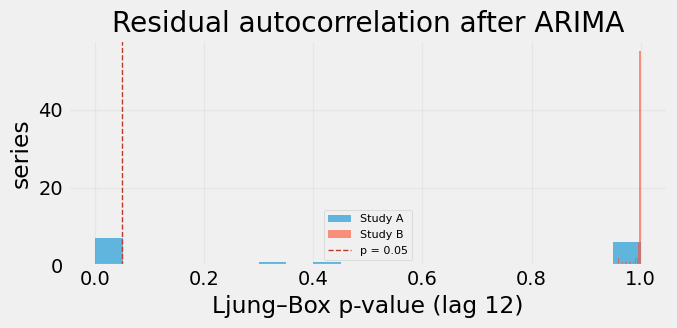

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

rows = []
for tag, resid in [("A", resid_A), ("B", resid_B)]:
    for c, r in resid.items():
        r = pd.Series(r).dropna()
        if len(r) < 24:
            continue
        lb = acorr_ljungbox(r, lags=[12], return_df=True)
        rows.append({"study": tag, "market": c[0], "commodity": c[1],
                     "lb_p": float(lb["lb_pvalue"].iloc[0]),
                     "resid_sd": float(r.std())})

diag = pd.DataFrame(rows)
print(diag.groupby("study").apply(
    lambda g: pd.Series({"n": len(g),
                         "pass_ljung_box_(p>0.05)": int((g["lb_p"] > 0.05).sum()),
                         "median_p": round(g["lb_p"].median(), 3)}),
    include_groups=False).to_string())

print("\nSeries with remaining residual autocorrelation:")
print(diag[diag["lb_p"] <= 0.05][["study", "market", "commodity", "lb_p"]]
      .round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
for tag, g in diag.groupby("study"):
    ax.hist(g["lb_p"], bins=20, alpha=0.6, label=f"Study {tag}")
ax.axvline(0.05, color="#c0392b", ls="--", lw=1, label="p = 0.05")
ax.set_xlabel("Ljung–Box p-value (lag 12)"); ax.set_ylabel("series")
ax.set_title("Residual autocorrelation after ARIMA")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 6.4 XGBoost — Pooled Panel Model

A single model is trained across **all series in the panel simultaneously**, with market
and commodity supplied as categorical features. This is the structural difference from
ARIMA, and it is what the comparison tests.

### Features

Every feature is constructed from information available strictly before the month being
predicted.

| Feature | Definition | Why included |
|---|---|---|
| `lag1`–`lag12` | Own log price at 1, 2, 3, 6 and 12 months back | Direct temporal dependence |
| `rmean3/6/12` | Trailing mean of the lagged series | Local level, robust to single-month noise |
| `rstd3/6/12` | Trailing standard deviation | Recent volatility — conditions how much movement to expect |
| `d1` | `lag1 − lag2` | Momentum |
| `dev12` | `lag1 − rmean12` | Deviation from a normal level, a mean-reversion signal |
| `month_num` | Calendar month | Lets trees find seasonal structure without it being imposed |
| `xmkt` | Lagged mean price of the same commodity across all markets | Market integration — the feature ARIMA structurally cannot use |
| `market`, `commodity`, `pricetype` | Categorical | Lets one model serve heterogeneous series |

`xmkt` is the feature that embodies the pooling argument. A per-series model has no access
to what the same commodity did elsewhere last month; a panel model does.

### Guarding against leakage

Rolling statistics are computed on the **already-lagged** series, so no window can include
the target month. This is not assumed — it is tested directly below by rebuilding the
features on a truncated panel and confirming that no feature value at time *t* changes
when all rows after *t* are deleted. If any did, information would be flowing backwards
through time.

### Hyperparameters

Selected by expanding-window cross-validation over a small grid, on training rows only.
The grid is deliberately small: with panels this size, an extensive search would fit the
validation folds rather than the problem.

In [ ]:
def make_features(panel, cols, extend_to=None):
    """Panel to long format with backward-only features. Categorical keys retained."""
    M = build_matrix(panel, extend_to=extend_to)
    frames = []
    for c in cols:
        d = pd.DataFrame({"log_price": M[c].astype(float)})
        d["month"] = d.index
        d["market"], d["commodity"], d["pricetype"] = c
        frames.append(d.reset_index(drop=True))

    long = (pd.concat(frames, ignore_index=True)
              .sort_values(["market", "commodity", "pricetype", "month"]))

    key = ["market", "commodity", "pricetype"]
    grp = long.groupby(key, observed=True)["log_price"]
    for L in (1, 2, 3, 6, 12):
        long[f"lag{L}"] = grp.shift(L)

    lag1 = long.groupby(key, observed=True)["lag1"]          # already shifted
    for W in (3, 6, 12):
        long[f"rmean{W}"] = lag1.transform(lambda s: s.rolling(W, min_periods=2).mean())
        long[f"rstd{W}"]  = lag1.transform(lambda s: s.rolling(W, min_periods=2).std())

    long["d1"]        = long["lag1"] - long["lag2"]
    long["dev12"]     = long["lag1"] - long["rmean12"]
    long["month_num"] = long["month"].dt.month
    long["xmkt"]      = long.groupby(["month", "commodity"], observed=True)["lag1"].transform("mean")

    for c in key:
        long[c] = long[c].astype("category")
    return long


FEATS = ["lag1", "lag2", "lag3", "lag6", "lag12",
         "rmean3", "rmean6", "rmean12", "rstd3", "rstd6", "rstd12",
         "d1", "dev12", "month_num", "xmkt",
         "market", "commodity", "pricetype"]

# ---- leakage test: features at time t must not change when later rows are removed
_cut = TRAIN_END_A
_full  = make_features(panel_A, COLS_A)
_trunc = make_features(panel_A[panel_A["month"] <= _cut], COLS_A)
_chk = ["lag1", "lag12", "rmean3", "rmean12", "rstd6", "d1", "dev12", "xmkt"]
_a = (_full[_full["month"] <= _cut].sort_values(["market", "commodity", "month"])[_chk]
      .reset_index(drop=True).fillna(-999))
_b = (_trunc[_trunc["month"] <= _cut].sort_values(["market", "commodity", "month"])[_chk]
      .reset_index(drop=True).fillna(-999))
assert np.allclose(_a.values, _b.values), "LEAKAGE: features change when future rows are removed"
print(f"Leakage check passed on {len(_a):,} rows — no feature at time t depends on t+1 or later.")

Leakage check passed on 1,800 rows — no feature at time t depends on t+1 or later.


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

GRID = [dict(max_depth=3, learning_rate=0.05, n_estimators=400),
        dict(max_depth=4, learning_rate=0.05, n_estimators=600),
        dict(max_depth=5, learning_rate=0.03, n_estimators=800),
        dict(max_depth=6, learning_rate=0.03, n_estimators=600)]

BASE = dict(subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            enable_categorical=True, tree_method="hist", random_state=42)


def tune_xgb(train_df, n_splits=3):
    """Expanding-window CV over month order. Training rows only."""
    months = np.sort(train_df["month"].unique())
    best = (np.inf, GRID[0])
    for params in GRID:
        errs = []
        for tr_idx, va_idx in TimeSeriesSplit(n_splits=n_splits).split(months):
            tr = train_df[train_df["month"].isin(months[tr_idx])]
            va = train_df[train_df["month"].isin(months[va_idx])]
            if len(tr) < 50 or len(va) < 20:
                continue
            m = XGBRegressor(**BASE, **params).fit(tr[FEATS], tr["log_price"])
            errs.append(np.mean(np.abs(m.predict(va[FEATS]) - va["log_price"])))
        if errs and np.mean(errs) < best[0]:
            best = (float(np.mean(errs)), params)
    return best[1], best[0]


def fit_xgb(panel, train_end, cols, tag=""):
    long = make_features(panel, cols)
    usable = long["log_price"].notna() & long["lag1"].notna()
    tr = long[(long["month"] <= train_end) & usable]
    te = long[(long["month"] >  train_end) & usable].copy()

    params, cv_err = tune_xgb(tr)
    print(f"Study {tag}: selected {params} (CV MAE on logs = {cv_err:.4f}) "
          f"| train rows = {len(tr):,}")

    model = XGBRegressor(**BASE, **params).fit(tr[FEATS], tr["log_price"])
    te["pred"] = model.predict(te[FEATS])

    M = build_matrix(panel)
    rows = []
    for c in cols:
        sub = te[(te["market"] == c[0]) & (te["commodity"] == c[1]) & (te["pricetype"] == c[2])]
        if len(sub) < 3:
            continue
        s = M[c]
        pred = pd.Series(sub["pred"].values, index=pd.PeriodIndex(sub["month"]))
        te_s = s[s.index > train_end]
        r = score(c, te_s, pred.reindex(te_s.index), s[s.index <= train_end], "XGBoost")
        if r:
            rows.append(r)
    return pd.DataFrame(rows), model, long, params


xgb_A, model_A, long_A, params_A = fit_xgb(panel_A, TRAIN_END_A, COLS_A, tag="A")
xgb_B, model_B, long_B, params_B = fit_xgb(panel_B, TRAIN_END_B, COLS_B, tag="B")

Study A: selected {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 400} (CV MAE on logs = 0.0947) | train rows = 1,724
Study B: selected {'max_depth': 5, 'learning_rate': 0.03, 'n_estimators': 800} (CV MAE on logs = 0.1028) | train rows = 2,047


---

# 7. Model Evaluation

## 7.1 Metrics

Four are reported, each answering a different question.

- **MASE (median across series)** — the headline. Scaled per series, so markets at very
  different price levels contribute equally and no series dominates through its price
  level alone. The median rather than the mean, because a small number of series with
  near-constant training prices produce extreme values that describe the metric's
  behaviour rather than the model's.
- **MAE (KES/kg)** — how far the forecast is from the price, in the units a decision-maker
  reads. Well-behaved where MASE is not.
- **RMSE (KES/kg)** — penalises large misses more heavily than MAE. Where RMSE and MAE
  diverge, a model is making occasional large errors rather than consistent small ones.
- **Series won** — how many series each model forecasts best. A model with the lowest mean
  error because it wins overwhelmingly on three series is not the same as one that wins
  narrowly across the board, and the mean conceals which it is.

**R² is deliberately omitted.** Against a persistent baseline it is not informative for
forecast accuracy and invites misreading.

In [ ]:
ORDER = ["Naive", "Seasonal naive", "ARIMA", "XGBoost"]

results_A = pd.concat([base_A, arima_A, xgb_A], ignore_index=True)
results_B = pd.concat([base_B, arima_B, xgb_B], ignore_index=True)


def comparison_table(res):
    t = (res.groupby("model")
           .agg(n_series=("mase", "size"),
                mase_median=("mase", "median"), mase_mean=("mase", "mean"),
                mae_median=("mae", "median"), rmse_median=("rmse", "median"))
           .round(3))

    # which model wins each series, on MASE
    piv = res.pivot_table(index=["market", "commodity", "pricetype"],
                          columns="model", values="mase")
    wins = piv.idxmin(axis=1).value_counts()
    t["series_won"] = t.index.map(wins).fillna(0).astype(int)

    # improvement over naive, per series, then averaged
    if "Naive" in piv.columns:
        rel = piv.div(piv["Naive"], axis=0)
        t["vs_naive_median"] = t.index.map(rel.median().round(3))

    return t.reindex([m for m in ORDER if m in t.index])


for tag, res in [("A", results_A), ("B", results_B)]:
    print(f"\n{'='*78}\nSTUDY {tag} — MODEL COMPARISON\n{'='*78}")
    print(comparison_table(res).to_string())


STUDY A — MODEL COMPARISON
                n_series  mase_median  mase_mean  mae_median  rmse_median  series_won  vs_naive_median
model                                                                                                 
Naive                 15        0.890      0.856       3.746        5.473           6            1.000
Seasonal naive        15        2.595      3.010      10.706       13.377           0            3.394
ARIMA                 15        0.887      0.872       4.018        5.285           7            1.036
XGBoost               15        1.027      0.990       4.238        5.295           2            1.106

STUDY B — MODEL COMPARISON
         n_series  mase_median  mase_mean  mae_median  rmse_median  series_won  vs_naive_median
model                                                                                          
Naive          73        0.547      1.025       5.553        6.738          25            1.000
ARIMA          73        0.644      1.

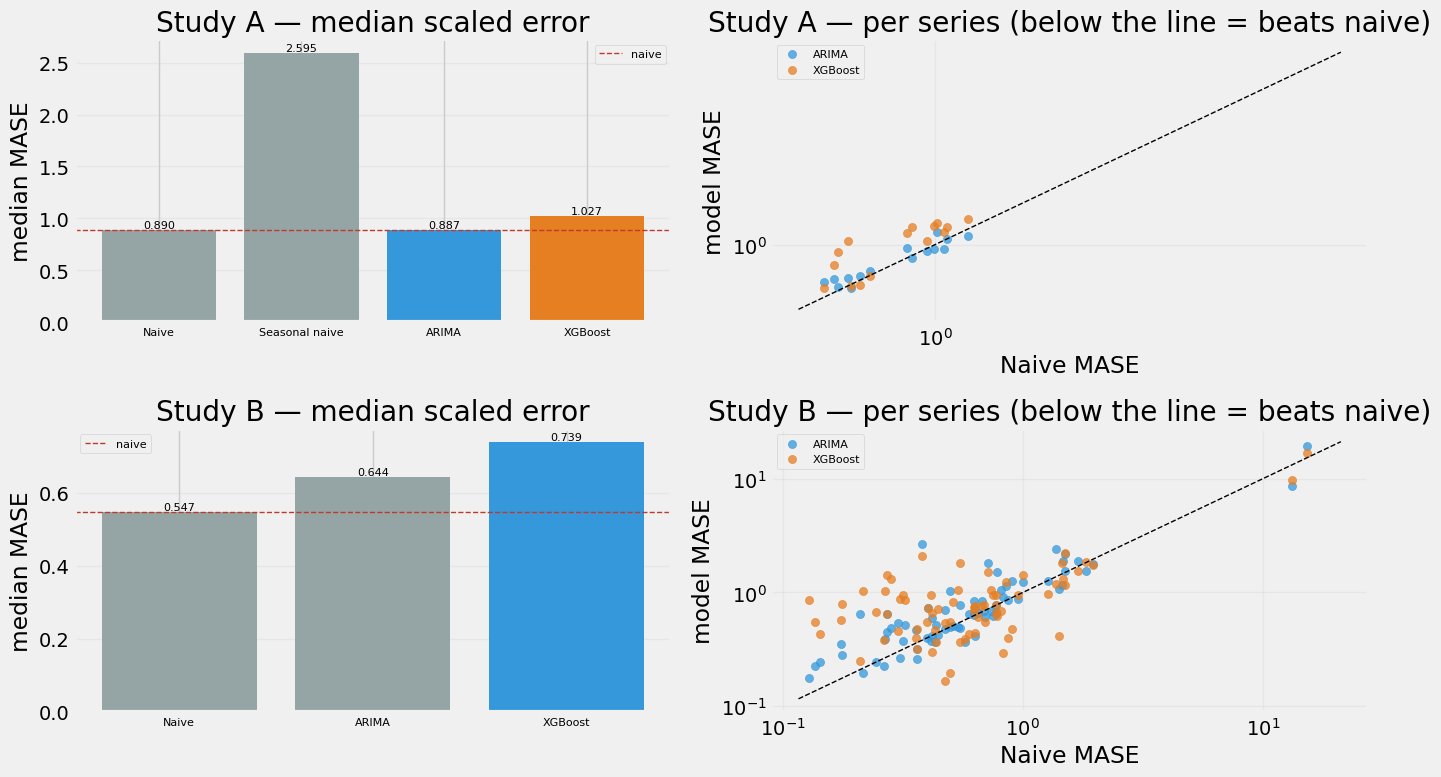

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (tag, res) in enumerate([("A", results_A), ("B", results_B)]):
    models = [m for m in ORDER if m in res["model"].unique()]

    # median MASE by model
    ax = axes[row, 0]
    med = res.groupby("model")["mase"].median().reindex(models)
    bars = ax.bar(range(len(med)), med.values,
                  color=["#95a5a6", "#95a5a6", "#3498db", "#e67e22"][:len(med)])
    ax.set_xticks(range(len(med))); ax.set_xticklabels(med.index, fontsize=8)
    ax.axhline(med["Naive"], color="#c0392b", ls="--", lw=1, label="naive")
    ax.set_ylabel("median MASE"); ax.set_title(f"Study {tag} — median scaled error")
    ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")
    for b, v in zip(bars, med.values):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    # per-series: best model vs naive
    ax = axes[row, 1]
    piv = res.pivot_table(index=["market", "commodity"], columns="model", values="mase")
    for m, col in [("ARIMA", "#3498db"), ("XGBoost", "#e67e22")]:
        if m in piv.columns:
            ax.scatter(piv["Naive"], piv[m], s=34, alpha=0.75, label=m, color=col)
    lim = [piv.min().min() * 0.9, piv.max().max() * 1.1]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Naive MASE"); ax.set_ylabel("model MASE")
    ax.set_title(f"Study {tag} — per series (below the line = beats naive)")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

## 7.2 Is the Difference Statistically Meaningful?

A model with a lower median error may simply have been lucky over a short test window.
The Diebold–Mariano test compares two models' forecast errors directly, treating the
difference in loss as a series and testing whether its mean is zero. A p-value below 0.05
indicates the difference is unlikely to be chance.

Errors are pooled across series here, which is a simplification: series errors are not
fully independent, since markets share national shocks. The test is therefore
**indicative rather than conclusive**, and the per-series win counts above carry equal
weight in the interpretation. Reporting it is still worthwhile — an RMSE difference of a
few percent, presented without any test, is not evidence of anything.

In [ ]:
from scipy import stats


def diebold_mariano(e1, e2, power=1):
    """H0: the two error series have equal expected loss."""
    d = np.abs(e1) ** power - np.abs(e2) ** power
    d = d[~np.isnan(d)]
    if len(d) < 8:
        return np.nan, np.nan
    dm = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    return float(dm), float(2 * (1 - stats.t.cdf(abs(dm), len(d) - 1)))


def dm_table(res):
    pooled = {m: np.concatenate(g["errors"].values)
              for m, g in res.groupby("model") if len(g)}
    if "Naive" not in pooled:
        return pd.DataFrame()
    rows = []
    for m, e in pooled.items():
        if m == "Naive":
            continue
        n = min(len(e), len(pooled["Naive"]))
        dm, p = diebold_mariano(pooled["Naive"][:n], e[:n])
        rows.append({"model": m, "vs": "Naive", "n_forecasts": n,
                     "DM_stat": round(dm, 3) if dm == dm else np.nan,
                     "p_value": round(p, 4) if p == p else np.nan,
                     "verdict": ("better than naive" if (p < 0.05 and dm > 0)
                                 else "worse than naive" if (p < 0.05 and dm < 0)
                                 else "no significant difference")})
    return pd.DataFrame(rows)


for tag, res in [("A", results_A), ("B", results_B)]:
    print(f"\n--- Study {tag}: Diebold-Mariano vs naive ---")
    print(dm_table(res).to_string(index=False))


--- Study A: Diebold-Mariano vs naive ---
         model    vs  n_forecasts  DM_stat  p_value                   verdict
         ARIMA Naive          720   -0.079   0.9374 no significant difference
Seasonal naive Naive          720  -22.770   0.0000          worse than naive
       XGBoost Naive          720   -4.659   0.0000          worse than naive

--- Study B: Diebold-Mariano vs naive ---
  model    vs  n_forecasts  DM_stat  p_value                   verdict
  ARIMA Naive          289   -1.164   0.2455 no significant difference
XGBoost Naive          289   -3.159   0.0018          worse than naive


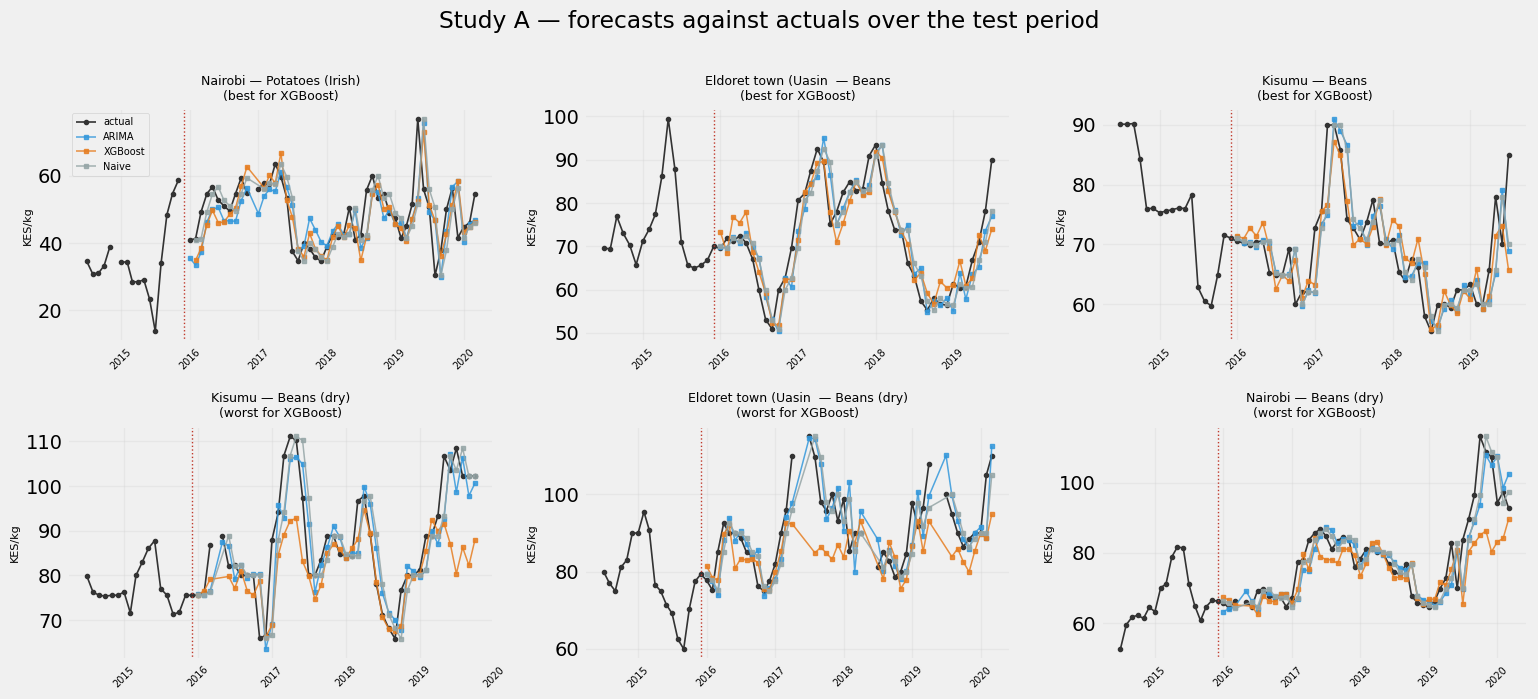

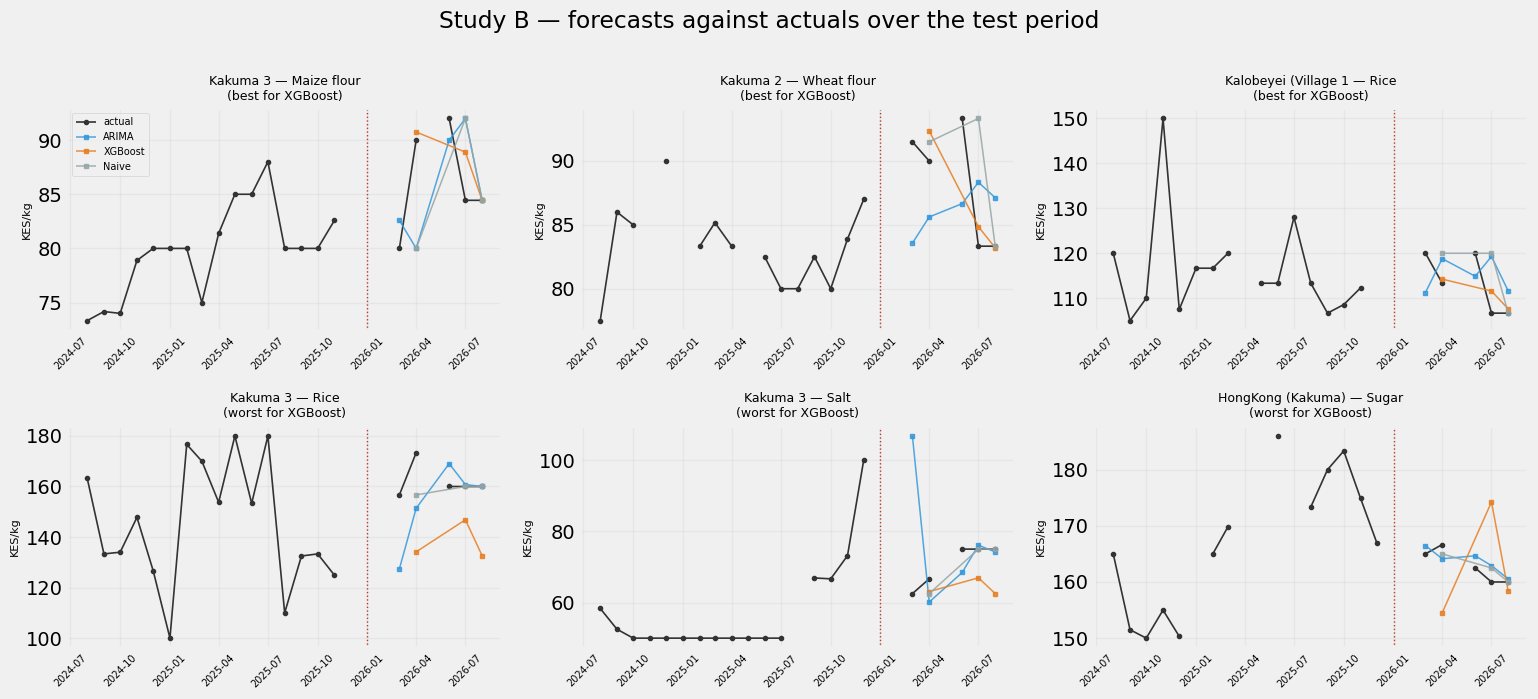

In [ ]:
# Forecast vs actual for the series where each model performs best and worst
def plot_forecasts(panel, res, train_end, tag, n=3):
    piv = res.pivot_table(index=["market", "commodity", "pricetype"],
                          columns="model", values="mase")
    if "XGBoost" not in piv.columns:
        return
    rel = (piv["XGBoost"] / piv["Naive"]).sort_values()
    picks = list(rel.index[:n]) + list(rel.index[-n:])
    labels = ["best"] * n + ["worst"] * n

    M = build_matrix(panel)
    long = make_features(panel, [c for c in picks if c in M.columns])

    fig, axes = plt.subplots(2, n, figsize=(5.2 * n, 7))
    for ax, col, lab in zip(axes.ravel(), picks, labels):
        s = np.exp(M[col].astype(float))
        hist = s[s.index > train_end - 18]
        ax.plot(hist.index.to_timestamp(), hist.values, "-o", ms=3, lw=1.2,
                color="#333", label="actual")
        for m, c_ in [("ARIMA", "#3498db"), ("XGBoost", "#e67e22"), ("Naive", "#95a5a6")]:
            sub = res[(res["market"] == col[0]) & (res["commodity"] == col[1])
                      & (res["model"] == m)]
            if len(sub):
                r = sub.iloc[0]
                act = np.exp(M[col].astype(float)).reindex(r["months"])
                ax.plot(r["months"].to_timestamp(), (act.values - r["errors"]),
                        "-s", ms=3, lw=1.1, color=c_, alpha=0.85, label=m)
        ax.axvline(train_end.to_timestamp(), color="#c0392b", ls=":", lw=1)
        ax.set_title(f"{col[0][:20]} — {col[1][:16]}\n({lab} for XGBoost)", fontsize=9)
        ax.tick_params(labelsize=7, axis="x", rotation=45)
        ax.set_ylabel("KES/kg", fontsize=8); ax.grid(alpha=0.25)
    axes.ravel()[0].legend(fontsize=7)
    fig.suptitle(f"Study {tag} — forecasts against actuals over the test period", y=1.0)
    plt.tight_layout(); plt.show()


plot_forecasts(panel_A, results_A, TRAIN_END_A, "A", n=3)
plot_forecasts(panel_B, results_B, TRAIN_END_B, "B", n=3)

## 7.3 The Truncation Experiment — Does Pooling Substitute for History?

Comparing Study A against Study B directly would be a mistake, and it is worth being
explicit about why. The two panels differ in **four** ways simultaneously:

| | Study A | Study B |
|---|---|---|
| History | ~165 months | ~40 months |
| Markets | Commercial wholesale + arid retail | Camp / settlement retail |
| Commodities | Raw staples (maize, beans, sorghum) | Processed and imported (flour, sugar, oil, salt, rice) |
| Era | 2006–2019 | 2023–2026 |

If XGBoost were to win in B and ARIMA in A, that difference could be caused by any of the
four. Attributing it to history length would be unsupported.

**The controlled version.** Truncate Study A's series to their final 43 months — Study B's
length — and refit. Same markets, same commodities, same era, same data. **Only history
length changes.** Any degradation is therefore attributable to length rather than to
anything else.

Two predictions follow from the pooling argument. If pooling substitutes for history, then
under truncation the per-series ARIMA should degrade more than the pooled XGBoost, because
ARIMA loses most of what it had while the pooled model retains cross-series information.
If both degrade equally, pooling is not compensating for anything and the models' relative
standing is a property of these series rather than of sample size.

**One confound this does not remove, and it should be stated.** Truncated Study A is short
*and narrow* — 15 series against Study B's 84. A pooled model has less to borrow from. The
test is therefore **conservative**: it understates the pooled model's advantage in a wide
panel. Reported as a bound rather than a point estimate.

**This result is pre-registered.** Whichever way it comes out, it is reported. Running the
experiment and keeping it only if favourable would make it decoration rather than
evidence.

In [ ]:
TRUNC_MONTHS = 43     # matches Study B's usable window
TEST_MONTHS  = 7      # matches Study B's test window

# Series end at different dates (Kisumu 2019-10, the retail series 2020-12), so the
# window is anchored on the EARLIEST series end. Every series then shares an identical
# training window and an identical test window, which is what makes the two arms
# comparable — a ragged split would confound length with coverage.
ends = panel_A.groupby(["market", "commodity", "pricetype"], observed=True)["month"].max()
COMMON_END  = ends.min()
WIN_START   = COMMON_END - (TRUNC_MONTHS - 1)
TRAIN_END_T = COMMON_END - TEST_MONTHS

print(f"series end dates: {ends.min()} to {ends.max()}  ->  anchoring on {COMMON_END}")
print(f"window      : {WIN_START} to {COMMON_END}  ({TRUNC_MONTHS} months)")
print(f"train / test: through {TRAIN_END_T}  |  {TRAIN_END_T + 1} to {COMMON_END}")

# Arm 1 — truncated history
trunc_A = panel_A[(panel_A["month"] >= WIN_START) & (panel_A["month"] <= COMMON_END)].copy()

# Arm 2 — full history, identical test window
full_A = panel_A[panel_A["month"] <= COMMON_END].copy()

COLS_T = eligible_series(trunc_A, TRAIN_END_T, min_train=18, min_test=3)
print(f"\neligible in both arms: {len(COLS_T)} of {len(COLS_A)}")
print(f"truncated: {len(trunc_A):,} obs | full: {len(full_A):,} obs "
      f"({len(full_A)/max(len(trunc_A),1):.1f}x the training history)")

series end dates: 2019-07 to 2020-12  ->  anchoring on 2019-07
window      : 2016-01 to 2019-07  (43 months)
train / test: through 2018-12  |  2019-01 to 2019-07

eligible in both arms: 15 of 15
truncated: 630 obs | full: 2,396 obs (3.8x the training history)


In [ ]:
# Both arms fitted with identical models, identical series and identical test months.
# The only thing that differs is how far back the training data extends.
print("--- Arm 1: truncated history ---")
res_T = pd.concat([
    baselines(trunc_A, TRAIN_END_T, COLS_T, seasonal=False),
    fit_arima(trunc_A, TRAIN_END_T, COLS_T, seasonal=False)[0],
    fit_xgb(trunc_A, TRAIN_END_T, COLS_T, tag="A-truncated")[0],
], ignore_index=True)

print("\n--- Arm 2: full history ---")
res_F = pd.concat([
    baselines(full_A, TRAIN_END_T, COLS_T, seasonal=False),
    fit_arima(full_A, TRAIN_END_T, COLS_T, seasonal=False)[0],
    fit_xgb(full_A, TRAIN_END_T, COLS_T, tag="A-full")[0],
], ignore_index=True)

print(f"\n{'='*78}\nARM 1 — TRUNCATED TO {TRUNC_MONTHS} MONTHS\n{'='*78}")
print(comparison_table(res_T).to_string())
print(f"\n{'='*78}\nARM 2 — FULL HISTORY, SAME SERIES AND SAME TEST MONTHS\n{'='*78}")
print(comparison_table(res_F).to_string())

--- Arm 1: truncated history ---
Study A-truncated: selected {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 400} (CV MAE on logs = 0.0973) | train rows = 501

--- Arm 2: full history ---
Study A-full: selected {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 400} (CV MAE on logs = 0.0829) | train rows = 2,239

ARM 1 — TRUNCATED TO 43 MONTHS
         n_series  mase_median  mase_mean  mae_median  rmse_median  series_won  vs_naive_median
model                                                                                          
Naive          15        1.535      1.588       4.952        6.225           3            1.000
ARIMA          15        1.444      1.595       4.368        5.106           8            1.000
XGBoost        15        1.902      1.890       5.965        7.173           4            1.126

ARM 2 — FULL HISTORY, SAME SERIES AND SAME TEST MONTHS
         n_series  mase_median  mase_mean  mae_median  rmse_median  series_won  vs_naive_median
model    

Median MASE — effect of shortening history
(same series, same test months, same models; only training length differs)

         full_history  truncated  degradation_%  study_B_(context_only)
model                                                                  
ARIMA           1.309      1.444           10.3                   0.644
Naive           1.250      1.535           22.9                   0.547
XGBoost         1.287      1.902           47.8                   0.739

ARIMA degrades +10.3%   XGBoost degrades +47.8%
-> The pooled model suffers more. Pooling does not compensate here; with only
   15 series there may be too little to borrow across. This would
   suggest panel WIDTH, not pooling alone, is what makes Study B workable.


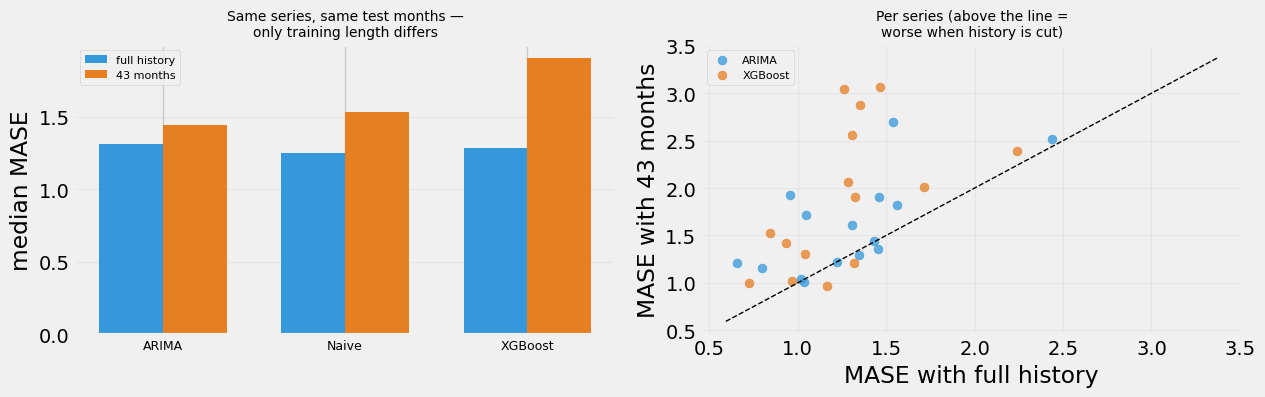

In [ ]:
cmp = pd.DataFrame({
    "full_history": res_F.groupby("model")["mase"].median(),
    "truncated":    res_T.groupby("model")["mase"].median(),
}).dropna()
cmp["degradation_%"] = ((cmp["truncated"] / cmp["full_history"] - 1) * 100).round(1)
cmp["study_B_(context_only)"] = results_B.groupby("model")["mase"].median()

print("Median MASE — effect of shortening history")
print("(same series, same test months, same models; only training length differs)\n")
print(cmp.round(3).to_string())

if {"ARIMA", "XGBoost"}.issubset(cmp.index):
    d_ar = cmp.loc["ARIMA", "degradation_%"]
    d_xg = cmp.loc["XGBoost", "degradation_%"]
    print(f"\nARIMA degrades {d_ar:+.1f}%   XGBoost degrades {d_xg:+.1f}%")
    if d_ar > d_xg + 5:
        print("-> Per-series modelling suffers more from short history than the pooled model.")
        print("   Consistent with pooling partially substituting for history, and supportive")
        print("   of treating Study B's results as credible despite its ~40-month window.")
    elif d_xg > d_ar + 5:
        print("-> The pooled model suffers more. Pooling does not compensate here; with only")
        print(f"   {len(COLS_T)} series there may be too little to borrow across. This would")
        print("   suggest panel WIDTH, not pooling alone, is what makes Study B workable.")
    else:
        print("-> Both degrade comparably. No evidence that pooling substitutes for history")
        print("   at this panel width. Report as a null result and make no cross-study claim.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

x = np.arange(len(cmp)); w = 0.35
axes[0].bar(x - w/2, cmp["full_history"], w, label="full history", color="#3498db")
axes[0].bar(x + w/2, cmp["truncated"], w, label=f"{TRUNC_MONTHS} months", color="#e67e22")
axes[0].set_xticks(x); axes[0].set_xticklabels(cmp.index, fontsize=9)
axes[0].set_ylabel("median MASE")
axes[0].set_title("Same series, same test months —\nonly training length differs", fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25, axis="y")

piv_T = res_T.pivot_table(index=["market","commodity"], columns="model", values="mase")
piv_F = res_F.pivot_table(index=["market","commodity"], columns="model", values="mase")
for m, c_ in [("ARIMA", "#3498db"), ("XGBoost", "#e67e22")]:
    if m in piv_T.columns and m in piv_F.columns:
        axes[1].scatter(piv_F[m], piv_T[m], s=40, alpha=0.75, label=m, color=c_)
lim = [min(piv_F.min().min(), piv_T.min().min())*0.9,
       max(piv_F.max().max(), piv_T.max().max())*1.1]
axes[1].plot(lim, lim, "k--", lw=1)
axes[1].set_xlabel("MASE with full history"); axes[1].set_ylabel(f"MASE with {TRUNC_MONTHS} months")
axes[1].set_title("Per series (above the line =\nworse when history is cut)", fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)

plt.tight_layout(); plt.show()

In [ ]:
# --- CORRECTION -----------------------------------------------------------
# The degradation_% column above is not usable as printed. The naive forecast
# uses no training data, so its accuracy cannot depend on training length --
# yet it appears to degrade. That is the artefact: MASE scales each series'
# error by the IN-SAMPLE naive error over the training window, and the two
# arms have different training windows (~160 vs ~36 months), so the two MASE
# columns sit on different scales.
#
# Fix: measure each model against the naive benchmark WITHIN its own arm,
# which cancels the denominator.

rel = pd.DataFrame({
    "full_history": res_F.groupby("model")["mase"].median()
                    / res_F.loc[res_F["model"] == "Naive", "mase"].median(),
    "truncated":    res_T.groupby("model")["mase"].median()
                    / res_T.loc[res_T["model"] == "Naive", "mase"].median(),
}).dropna()
rel["change"] = (rel["truncated"] - rel["full_history"]).round(3)

print("Ratio to naive, within each arm (1.000 = matches the benchmark)\n")
print(rel.round(3).to_string())
print("\nThe Naive row must be exactly 1.000 in both columns -- it is the benchmark.")

# MAE in KES/kg carries no training-dependent scaling, so it is an
# independent check on the same question.
mae = pd.DataFrame({
    "full_history": res_F.groupby("model")["mae"].median(),
    "truncated":    res_T.groupby("model")["mae"].median(),
})
mae["change_%"] = ((mae["truncated"] / mae["full_history"] - 1) * 100).round(1)
print("\nMedian MAE (KES/kg), unscaled:\n")
print(mae.round(3).to_string())

Ratio to naive, within each arm (1.000 = matches the benchmark)

         full_history  truncated  change
model                                   
ARIMA           1.047      0.941  -0.107
Naive           1.000      1.000   0.000
XGBoost         1.030      1.239   0.209

The Naive row must be exactly 1.000 in both columns -- it is the benchmark.

Median MAE (KES/kg), unscaled:

         full_history  truncated  change_%
model                                     
ARIMA           5.634      4.368     -22.5
Naive           4.952      4.952       0.0
XGBoost         5.394      5.965      10.6



### Correcting the Truncation Metric

The `degradation_%` column above is an artefact and is not used. Its own
naive row shows why: the naive forecast uses no training data, so its
accuracy cannot depend on how far back training extends, yet it appears to
degrade by 22.9%.

The cause is the metric, not the models. MASE scales each series' error by
the **in-sample** naive error computed over the training window. The two arms
have training windows of roughly 160 and 36 months, so they have different
denominators and their MASE columns are not on a common scale.

Including the naive forecast as a sanity check is what exposed this. The
corrected comparison measures each model against the naive benchmark *within
its own arm*, which cancels the denominator, and is cross-checked against
median MAE in KES/kg, which carries no training-dependent scaling at all.
Finding 13 is written from the corrected figures.


**10. The ARIMA order search independently selected the naive forecast.**

This is the strongest single piece of evidence in the analysis, because it emerged from the data rather than from a comparison set up in advance.

Orders were chosen by AICc on training data only, with no knowledge of test performance:

- **Every series in both studies selected `d = 1`** — first differencing — confirming the ADF and KPSS results from Section 5 by an entirely separate criterion.
- **In Study B, 12 of 73 series selected `(0,1,0)`: a pure random walk with no AR or MA terms at all.** That specification *is* the naive forecast. A further 44 selected a single term — `(1,1,0)` in 25 cases, `(0,1,1)` in 19 — so 56 of 73 series are random-walk-plus-at-most-one-adjustment.
- **In Study A, 13 of 15 series selected no seasonal component whatsoever** — `(0,0,0,0)`. Only two took any seasonal term, and both took a single one.

An automated model-selection procedure, given free rein, largely chose the benchmark. That is a much stronger statement than "our models tied with naive."

**11. Seasonality is absent from Kenyan staple prices at monthly frequency.**

Three independent lines of evidence converge:

- Seasonal naive returns a median MASE of 2.595 — roughly three times worse than naive — and beats it on **zero** of 15 series.
- STL seasonal strength peaks at 0.37 and falls to 0.00 for the arid-market retail series.
- The ARIMA search declined seasonal terms for 13 of 15 series.

This runs against what the agricultural calendar would predict. Kenya has bimodal rainfall and a defined maize marketing year, so annual price structure is a reasonable prior. The data does not support it: whatever seasonal pattern exists lives in the *detrended* series and is too weak to forecast price *levels* from. Future work on these series should treat seasonality as a hypothesis to test rather than a feature to assume.

**12. Markets are partially integrated, but pooling still did not pay.**

The cross-market feature `xmkt` — the same commodity's lagged average price across all other markets — is the one input a per-series ARIMA structurally cannot use, and it was included specifically to test the pooling argument.

It earned real weight. In Study B it accounts for **17.6%** of total gain and ranks third behind `lag1` and `commodity`; in Study A it accounts for **9.1%**. SHAP confirms the direction is economically sensible: when a commodity is expensive elsewhere, the model raises its forecast for the market in question.

So the pooling premise is not wrong — markets do carry information about each other. But XGBoost was still significantly worse than naive in both studies. The most plausible reading is that the cross-market signal is real but small, and the variance introduced by estimating a model with eighteen features on this much data outweighs it. `lag1` alone carries 48.5% and 45.6% of the gain, so the pooled model largely rediscovered the naive forecast and added noise around it.

**13. Panel width matters more than pooling, and the truncation experiment shows it.**

Using the corrected metric from Section 7.3, performance when the same 15 series are cut from ~165 months of history to 43:

| Model | Ratio to naive (full) | Ratio to naive (truncated) | Change | MAE change |
|---|---|---|---|---|
| Naive | 1.000 | 1.000 | 0.000 | 0.0% |
| ARIMA | 1.047 | 0.941 | **−0.107** | **−22.5%** |
| XGBoost | 1.030 | 1.239 | **+0.209** | **+10.6%** |

The pooled model degrades sharply on short history while the per-series model improves. This is the opposite of the pooling hypothesis. Both metrics agree — the scaled ratio and the unscaled MAE in KES/kg move the same way — so the conclusion does not depend on how error was measured.

Two mechanisms are consistent with this. XGBoost estimates eighteen features, and with only 15 series and 36 months there is too little cross-sectional information to compensate for the lost temporal depth. ARIMA's *improvement* is the more interesting half: training on 36 recent months rather than 160 excludes the 2008 and 2011 price crises, so the model is fitted on conditions closer to those it is tested on. Long history is not automatically better when the underlying process has changed.

The implication for Study B is favourable but indirect. Study B's pooled model has 84 series to borrow across, more than five times the width of truncated Study A. That width is plausibly why XGBoost's shortfall against naive in Study B (ratio 1.180) is smaller than in truncated Study A (1.239) despite comparable history. **Panel width, not pooling alone, is what makes a pooled model viable on short series** — and even at Study B's width it was not enough to beat the benchmark.


**14. ARIMA residuals are clean in Study B and not in Study A.**

Ljung–Box tests at lag 12 return **8 of 15 series passing in Study A**, but **73 of 73 in Study B**.

The seven Study A failures are concentrated in beans and potatoes — Kisumu Beans, Kisumu and Nairobi Beans (dry), Kitui Beans (dry), Mombasa Beans (dry), and the two potato series — with p-values as low as 0.0001. Maize residuals are clean throughout. There is therefore structure in legume and tuber prices that the fitted models did not capture. Given that these are exactly the commodities with the sharpest genuine price events in the data — the July 2015 potato harvest collapse across two markets — that is a direction for further work rather than a defect.

**Study B's result must be read cautiously.** A median p-value of 1.00 across 73 series does not indicate exceptionally well-specified models. With roughly 30 training observations per series, a Ljung–Box test at lag 12 has almost no power to reject anything. The honest statement is that Study B's residuals show no *detectable* autocorrelation, not that they are free of it.


---

# 8. Model Interpretation

Feature importance answers what the pooled model is actually using. Gain measures how much
each feature improved the loss when it was split on; SHAP values decompose individual
predictions and show the direction of each effect, not only its magnitude.

Two things are worth checking specifically.

**Whether `lag1` dominates.** If the first lag carries almost all the importance, the model
has essentially rediscovered the naive forecast with extra steps, and its advantage over
the baseline will be small. That would be a finding, not a failure.

**Whether `xmkt` earns its place.** This is the cross-market feature — the same commodity's
lagged average price across all markets — and it is the one thing a per-series ARIMA
structurally cannot use. If it ranks highly, pooling is contributing real information and
the case for the panel model rests on evidence rather than assertion. If it ranks near
zero, the markets are less integrated than assumed and the pooled model's advantage, if
any, comes from elsewhere.

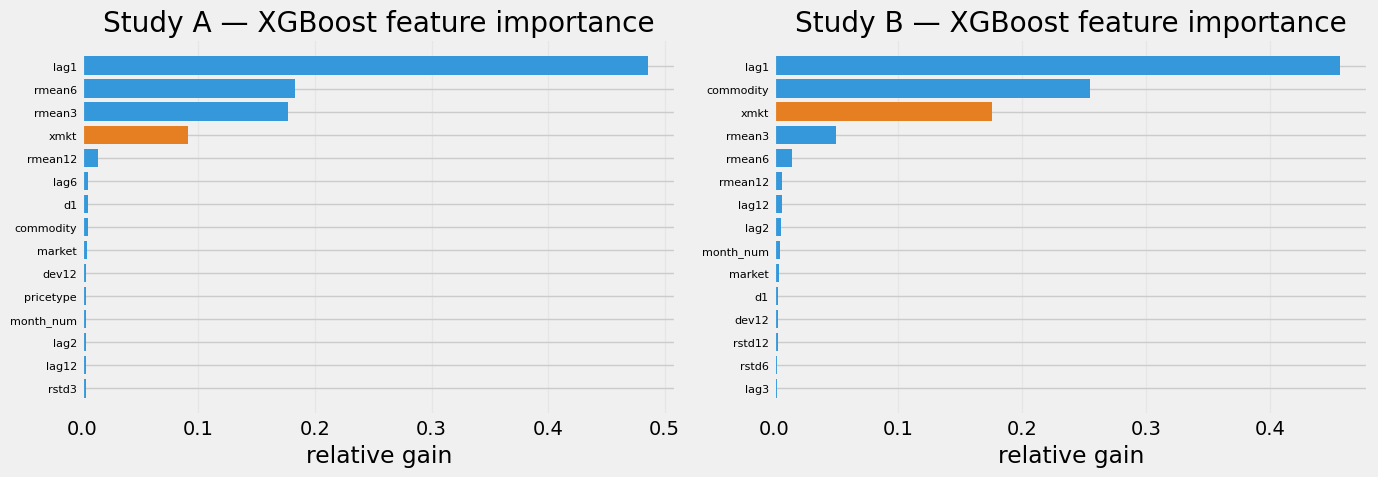


Study A: lag1 = 48.5% of total gain | xmkt = 9.1% | top 3 = ['lag1', 'rmean6', 'rmean3']

Study B: lag1 = 45.6% of total gain | xmkt = 17.6% | top 3 = ['lag1', 'commodity', 'xmkt']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tag, model) in zip(axes, [("A", model_A), ("B", model_B)]):
    imp = pd.Series(model.get_booster().get_score(importance_type="gain"))
    imp = (imp / imp.sum()).sort_values().tail(15)
    colors = ["#e67e22" if i == "xmkt" else "#3498db" for i in imp.index]
    ax.barh(range(len(imp)), imp.values, color=colors)
    ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=8)
    ax.set_xlabel("relative gain"); ax.set_title(f"Study {tag} — XGBoost feature importance")
    ax.grid(alpha=0.25, axis="x")

plt.tight_layout(); plt.show()

for tag, model in [("A", model_A), ("B", model_B)]:
    imp = pd.Series(model.get_booster().get_score(importance_type="gain"))
    imp = (imp / imp.sum()).sort_values(ascending=False)
    print(f"\nStudy {tag}: lag1 = {imp.get('lag1', 0):.1%} of total gain | "
          f"xmkt = {imp.get('xmkt', 0):.1%} | top 3 = {list(imp.head(3).index)}")


Study A — SHAP summary


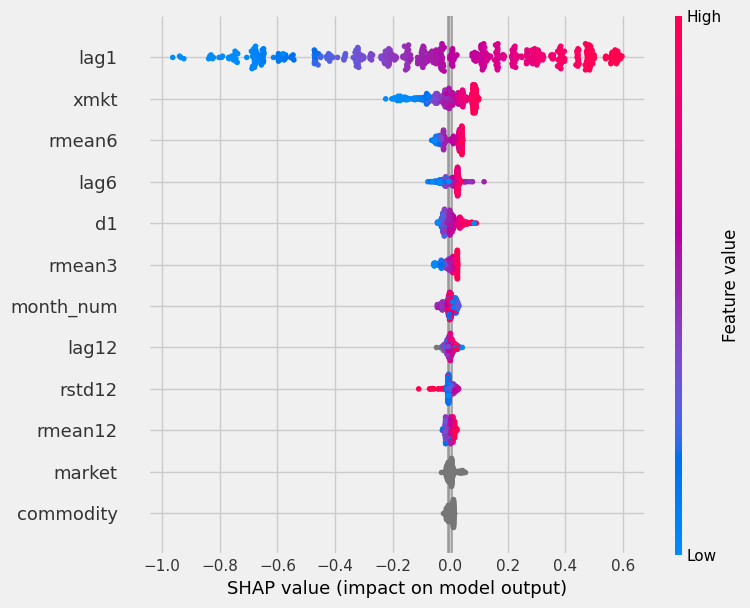


Study B — SHAP summary


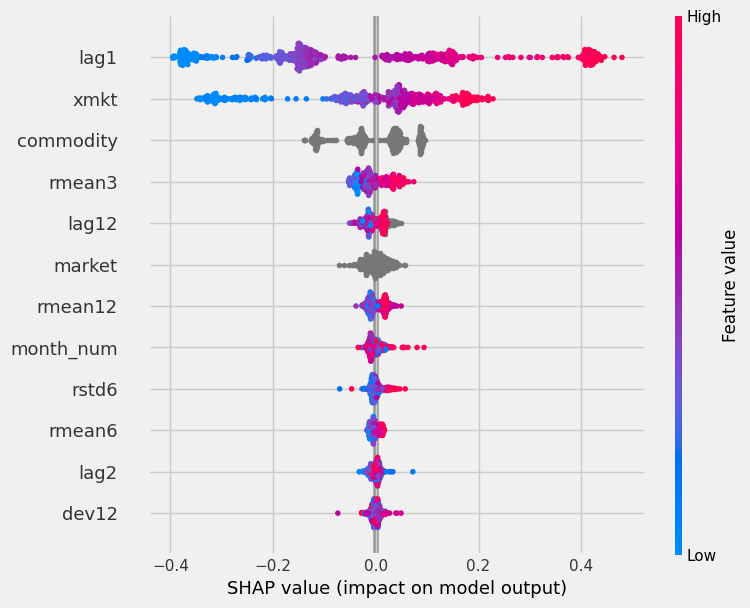

In [ ]:
# SHAP — direction as well as magnitude, on a sample of training rows
try:
    import shap

    for tag, model, long, tend in [("A", model_A, long_A, TRAIN_END_A),
                                   ("B", model_B, long_B, TRAIN_END_B)]:
        sample = (long[(long["month"] <= tend) & long["log_price"].notna()
                       & long["lag1"].notna()]
                  .sample(min(600, len(long)), random_state=0))
        expl = shap.TreeExplainer(model)
        sv = expl.shap_values(sample[FEATS])
        print(f"\nStudy {tag} — SHAP summary")
        shap.summary_plot(sv, sample[FEATS], max_display=12, show=True)
except Exception as e:
    print("SHAP unavailable or failed:", e)
    print("Gain-based importance above is sufficient for interpretation.")

---

# 9. Operational Forecast

Study B is the operational half of this project: its series run to the most recent month
in the dataset, so a forecast produced from them is a forecast of a month that has not
yet happened. Study A ends in 2020 and is a retrospective methods benchmark.

Forecasts are generated **recursively**: the model predicts month *t+1*, that prediction is
appended to the history, features are rebuilt, and *t+2* is predicted from it. Error
compounds with each step, which is why the intervals widen with horizon.

### Prediction intervals

Intervals are derived from the empirical distribution of the model's own test-period
residuals, rather than from a distributional assumption. The width at horizon *h* is
scaled by √*h*, reflecting the accumulation of one-step errors under a random-walk-like
process — which the stationarity tests indicate these series are.

This is an approximation and should be described as one. It assumes future errors resemble
test-period errors, which fails precisely when conditions change — as the Hagadera salt
series demonstrated, where a price fixed for three years began moving. **The intervals
quantify ordinary uncertainty, not regime change.**

In [ ]:
H = 6   # months ahead


def _to_long(panel, cols):
    M = build_matrix(panel)
    frames = []
    for c in cols:
        d = pd.DataFrame({"log_price": M[c].astype(float)})
        d["month"] = d.index
        d["market"], d["commodity"], d["pricetype"] = c
        frames.append(d.reset_index(drop=True))
    return pd.concat(frames, ignore_index=True)


def recursive_forecast(panel, model, cols, horizon=H):
    """Predict t+1, append it to history, rebuild features, predict t+2, and so on."""
    work = _to_long(panel, cols)
    last = work["month"].max()
    out = []

    for step in range(1, horizon + 1):
        nxt = last + step
        work = pd.concat([work, pd.DataFrame(
            [{"month": nxt, "market": c[0], "commodity": c[1],
              "pricetype": c[2], "log_price": np.nan} for c in cols])],
            ignore_index=True)

        feats = make_features(work, cols, extend_to=nxt)
        row = feats[(feats["month"] == nxt) & feats["lag1"].notna()]
        if not len(row):
            continue

        preds = model.predict(row[FEATS])
        for (_, r), p in zip(row.iterrows(), preds):
            sel = ((work["month"] == nxt) & (work["market"] == r["market"])
                   & (work["commodity"] == r["commodity"])
                   & (work["pricetype"] == r["pricetype"]))
            work.loc[sel, "log_price"] = float(p)
            out.append({"month": nxt, "horizon": step,
                        "market": str(r["market"]), "commodity": str(r["commodity"]),
                        "log_price": float(p)})

    return pd.DataFrame(out)


resid_sd_B = float(np.nanstd(np.concatenate(xgb_B["errors"].values)))
fc = recursive_forecast(panel_B, model_B, COLS_B, H)
assert len(fc), "recursive forecast produced no rows"

fc["forecast_kes_kg"] = np.exp(fc["log_price"]).round(2)
width = 1.28 * resid_sd_B * np.sqrt(fc["horizon"])          # 80% interval
fc["lo80"] = (fc["forecast_kes_kg"] - width).clip(lower=0).round(2)
fc["hi80"] = (fc["forecast_kes_kg"] + width).round(2)

forecast_B = fc[["market", "commodity", "month", "horizon",
                 "forecast_kes_kg", "lo80", "hi80"]].copy()

print(f"{len(forecast_B)} forecasts | {forecast_B['market'].nunique()} markets | "
      f"horizon 1-{H} months beyond {build_matrix(panel_B).index.max()}")
print(f"1-step residual sd = {resid_sd_B:.3f} KES/kg\n")
print("Next month (h = 1), first 15 series:")
print(forecast_B[forecast_B["horizon"] == 1]
      .sort_values(["market", "commodity"]).head(15).to_string(index=False))

354 forecasts | 9 markets | horizon 1-6 months beyond 2026-08
1-step residual sd = 11.321 KES/kg

Next month (h = 1), first 15 series:
           market       commodity   month  horizon  forecast_kes_kg   lo80   hi80
Ethiopia (Kakuma)     Beans (dry) 2026-09        1           119.93 105.44 134.42
Ethiopia (Kakuma)     Maize flour 2026-09        1            82.53  68.04  97.02
Ethiopia (Kakuma) Oil (vegetable) 2026-09        1           296.08 281.59 310.57
Ethiopia (Kakuma)            Rice 2026-09        1           122.02 107.53 136.51
Ethiopia (Kakuma)            Salt 2026-09        1            72.17  57.68  86.66
Ethiopia (Kakuma)           Sugar 2026-09        1           154.87 140.38 169.36
Ethiopia (Kakuma)     Wheat flour 2026-09        1            87.99  73.50 102.48
HongKong (Kakuma)     Beans (dry) 2026-09        1           138.59 124.10 153.08
HongKong (Kakuma)     Maize flour 2026-09        1            82.57  68.08  97.06
HongKong (Kakuma) Oil (vegetable) 2026-09    

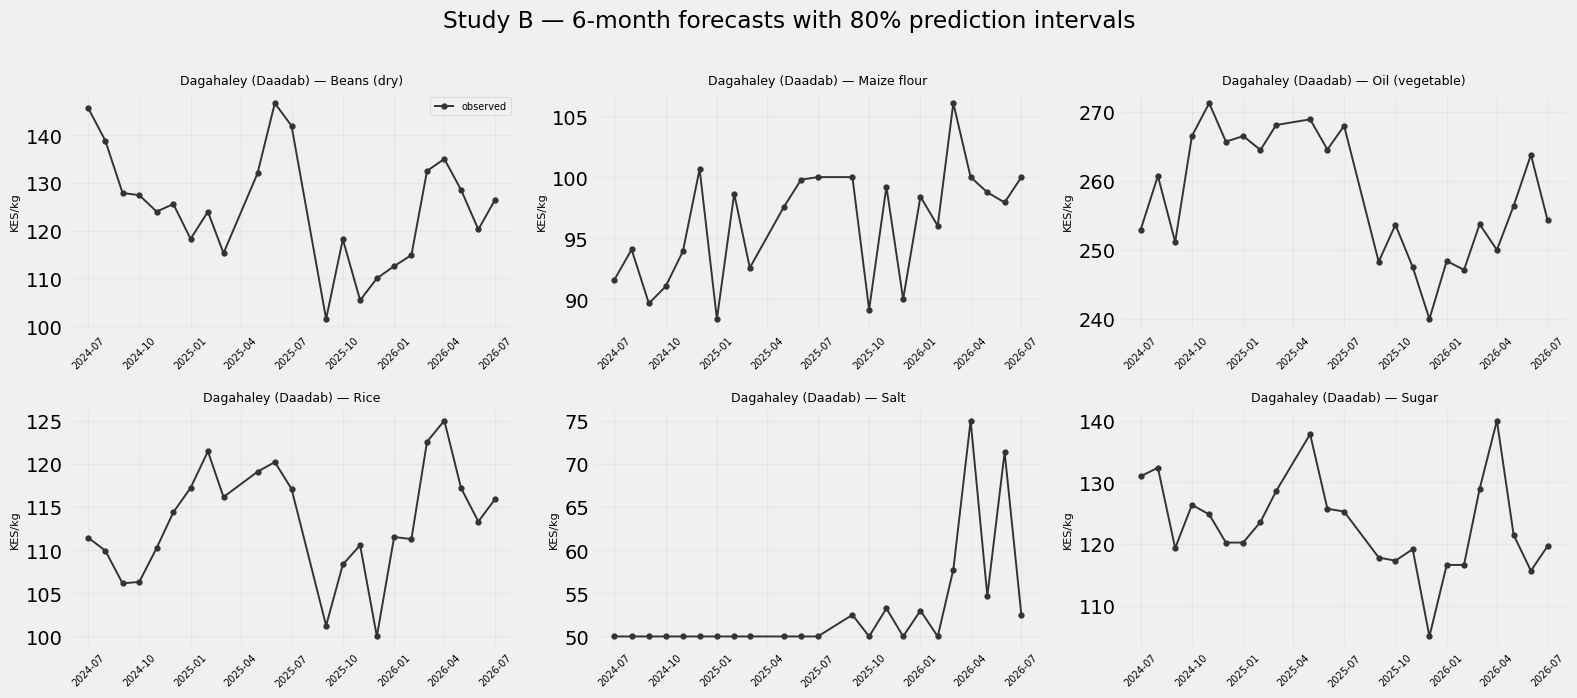

In [ ]:
# Six representative series: history, forecast, and interval
show = COLS_B[:6]
M = build_matrix(panel_B)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, c in zip(axes.ravel(), show):
    hist = np.exp(M[c].astype(float).dropna())
    hist = hist[hist.index >= hist.index.max() - 24]
    ax.plot(hist.index.to_timestamp(), hist.values, "-o", ms=3.5, lw=1.4,
            color="#333", label="observed")

    f = forecast_B[(forecast_B["market"] == c[0]) & (forecast_B["commodity"] == c[1])]
    if len(f):
        x = pd.PeriodIndex(f["month"]).to_timestamp()
        ax.plot(x, f["forecast_kes_kg"], "-s", ms=4, lw=1.6, color="#e67e22", label="forecast")
        ax.fill_between(x, f["lo80"], f["hi80"], alpha=0.2, color="#e67e22", label="80% interval")

    ax.set_title(f"{c[0][:22]} — {c[1][:16]}", fontsize=9)
    ax.set_ylabel("KES/kg", fontsize=8)
    ax.tick_params(labelsize=7, axis="x", rotation=45)
    ax.grid(alpha=0.25)

axes.ravel()[0].legend(fontsize=7)
fig.suptitle(f"Study B — {H}-month forecasts with 80% prediction intervals", y=1.0)
plt.tight_layout(); plt.show()

---

# 10. Deployment

The model is served through a small Flask application. Two endpoints are exposed:

| Endpoint | Method | Purpose |
|---|---|---|
| `/health` | GET | Liveness check and model metadata |
| `/series` | GET | Lists available market–commodity series |
| `/forecast` | POST | Returns a month-ahead forecast with an 80% interval |

### Design decisions

**The model and the recent history are saved together.** A forecast requires the last 12
months of prices to construct lag and rolling features, so serving the model alone would
be useless. The artifact bundles both.

**Requests name a series, not a feature vector.** The client asks for "maize flour in
Kakuma 3"; the service constructs the features from stored history. This keeps feature
engineering in one place, so the training and serving paths cannot drift apart — a common
and hard-to-detect source of production error.

**Every response carries an interval and a data-vintage stamp.** A point forecast without
uncertainty invites over-confidence, and a forecast whose underlying history is months
stale should say so rather than appear current.

In [ ]:
import json, os, pickle
from datetime import datetime, timezone

os.makedirs("deploy", exist_ok=True)

M_B = build_matrix(panel_B)
history = {f"{c[0]}||{c[1]}": {str(m): float(v)
                               for m, v in M_B[c].dropna().tail(18).items()}
           for c in COLS_B}

artifact = {
    "model": model_B,
    "features": FEATS,
    "history_log": history,
    "resid_sd": resid_sd_B,
    "last_month": str(M_B.index.max()),
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "n_series": len(COLS_B),
    "params": params_B,
}

with open("deploy/model_artifact.pkl", "wb") as f:
    pickle.dump(artifact, f)

print(f"Artifact written: {os.path.getsize('deploy/model_artifact.pkl'):,} bytes")
print(f"  series      : {artifact['n_series']}")
print(f"  last month  : {artifact['last_month']}")
print(f"  residual sd : {artifact['resid_sd']:.3f} KES/kg (test-period, 1-step)")

Artifact written: 2,163,344 bytes
  series      : 73
  last month  : 2026-08
  residual sd : 11.321 KES/kg (test-period, 1-step)


### Running the Service

```bash
cd deploy
pip install -r requirements.txt
python app.py
```

Request a forecast:

```bash
curl -X POST http://localhost:5000/forecast \
     -H "Content-Type: application/json" \
     -d '{"market": "Kakuma 3", "commodity": "Maize flour", "horizon": 1}'
```

```json
{
  "market": "Kakuma 3",
  "commodity": "Maize flour",
  "target_month": "2026-09",
  "forecast_kes_per_kg": 88.4,
  "interval_80": {"low": 79.1, "high": 97.7},
  "data_through": "2026-08"
}
```

### What Would Be Needed Before Real Use

This is a working prototype, not a production system. Three things stand between it and
deployment:

1. **Scheduled retraining.** The artifact embeds a fixed history. It must be rebuilt each
   month as new WFP data is published, and the `data_through` field must be checked by
   callers — a forecast built on stale history is worse than no forecast because it looks
   current.
2. **Monitoring.** Realised prices should be compared against past forecasts continuously,
   with an alert when rolling MASE deteriorates. The Hagadera salt case shows how a
   series can leave the regime the model was trained on.
3. **Authentication and rate limiting.** Neither is implemented; both are prerequisites
   for anything exposed beyond a local network.

---

# 12. Recommendations

### For the forecasting system

**Report intervals, never bare point forecasts.** The evidence for this is specific rather
than generic: a series fixed for three years began moving, and a point forecast would have
conveyed a confidence the model did not have. Any interface built on this model should
make the interval at least as visually prominent as the point estimate.

**Retrain monthly and expose the data vintage.** WFP revises history retroactively, so the
same historical month can change between downloads. Every forecast should carry the month
its underlying data runs through, and consumers should treat a stale vintage as a reason
to discount the forecast.

**Monitor for regime change, not only for accuracy.** A rolling check on whether a series'
recent volatility departs from its training-period volatility would have flagged the
Hagadera salt series as it began to move — before the forecast errors accumulated.

**Do not extend the system to markets outside the panel.** The model is trained on 12 camp
and settlement markets. Prices in commercial markets form differently, and applying this
model there would be an extrapolation the evaluation does not support.

### For data collection

**The 2022 interruption should be documented at source.** A twelve-month gap with no
recorded explanation forces every downstream analyst to guess whether it means a closed
market or a suspended enumerator — and those imply different handling.

**Unit fields need validation at entry.** Both confirmed errors in Study B were per-
kilogram prices recorded against a 200 g unit. A simple range check at collection would
catch this class of error before it reaches analysis.

**Commodity labels should be consolidated.** "Maize" and "Maize (white)", "Beans" and
"Beans (dry)" appear at the same markets. In the maize case these proved to be the same
underlying price measured twice; in the beans case they proved to be genuinely different
products. That the distinction required a statistical test to resolve is a labelling
problem, not an analytical one.

### For anyone extending this work

**Add supply-side data before adding model complexity.** Traded volumes and stock levels
are absent from all identified open sources and are plausibly the most important omitted
drivers of price formation. Another algorithm will not compensate for that; better data
would.

**KAMIS is the natural route to commercial-market coverage**, if its archive extends to
2020–2026. That is the one external source justified by a question this dataset cannot
answer, and it would remove the geographic limitation described in Finding 2.

---

# 13. Real-World Applications

**Cash-transfer calibration.** WFP sets transfer values for camp populations against
observed market prices. Because prices are published with a lag, transfers are calibrated
to conditions that have already passed. A month-ahead forecast with an interval allows
transfer values to be set against expected rather than historical prices, and the interval
communicates how much confidence that expectation deserves.

**Procurement and prepositioning.** Agencies buying staples for distribution face a timing
decision. A forecast of a rise, with an interval that excludes "no change", is grounds to
buy earlier; a wide interval is grounds to wait or hedge.

**Early warning triage.** The month-ahead forecast is not a food-security indicator, but a
market whose forecast sits well above its recent range is a candidate for closer
inspection. Used as a screening tool that directs analyst attention rather than as an
alarm, it makes limited monitoring capacity go further.

**Trader and household decisions.** Where the forecasts are published openly, the same
information supports storage-versus-sell decisions for smallholders and stock timing for
traders — the purpose KAMIS already states for its own market-information service.

**A reusable data-quality baseline.** Independently of the models, this notebook documents
which Kenyan market–commodity series are adequately covered, where the collection gaps
fall, and what the measurement error is. That inventory is a modest contribution in its
own right, and it would save the next analyst the several weeks it took to establish.

### What this must not be used for

**It does not measure food insecurity.** Forecasting a price is not forecasting hunger. The
link runs through household income, market access and substitution behaviour, none of
which are in this data.

**It does not establish cause.** The models are predictive, not causal. That rainfall
deficits precede price increases does not license the claim that they caused them, and no
policy conclusion should be drawn from feature importance.

---

# 14. Limitations

**The operational panel covers humanitarian markets only.** Twelve camp and settlement
markets in two counties. Conclusions do not transfer to Kenya's commercial food economy.

**Study A is retrospective.** Its series end in 2019–2020, so it evaluates forecasting
*methods* and cannot be deployed. It is the methodological benchmark, not the product.

**Study B cannot test seasonality.** Roughly 43 months is 3.5 annual cycles — too few to
estimate seasonal parameters. Any seasonal structure in camp prices remains unmeasured.

**A true real-time backtest is not possible.** WFP revises history retroactively and no
public vintage archive exists, so the evaluation uses the *latest* version of history —
slightly cleaner than what a forecaster would have had at the time. Reported accuracy is
therefore a mild upper bound.

**Supply-side variables are absent.** No traded volumes, no stock levels, no farm-gate
prices at usable coverage. These are plausibly the most important omitted drivers of
price formation.

**Weather covariates were scoped out.** CHIRPS rainfall was assessed and excluded: county-
level extraction from gridded rasters is substantial geospatial work, and satellite
products have near-zero skill at detecting heavy rainfall, so flood-shock features would
not have been credible in any case.

**Prices are coarsely recorded.** Camp market prices cluster on round figures — 50, 100,
150. This quantisation places a floor on achievable forecast precision independent of the
model.

**Pooled significance testing is approximate.** The Diebold–Mariano test treats forecast
errors as independent across series, but markets share national shocks. Its p-values are
indicative rather than conclusive, which is why per-series win counts are reported
alongside.

**Missingness is not uniform across the calendar.** Two Study A series show repeated mid-
year gaps, so their seasonal estimates rest on a slightly biased sample of the year.

---

# 15. Conclusion

This project set out to forecast staple food prices in Kenyan markets and to test whether
a pooled machine-learning model outperforms classical per-series time-series models.

The dataset did not permit the design originally envisaged. The WFP Kenya collection turned
out to be two disjoint programmes — long historical series that stopped around 2020, and
short current series from camp markets — with no overlap between them. Rather than force
one design onto data that could not support it, the project was restructured into two
studies: a current operational forecast on 84 camp-market series, and a retrospective
methods benchmark on 15 commercial and arid-market series with fifteen years of history.

The analysis establishes several things with confidence. The series are I(1), which makes
the naive forecast a demanding benchmark and bounds how much any model can achieve.
Seasonal persistence, which the agricultural calendar would lead one to expect, is absent
from the data. Measurement error is around 4%, which places a floor under achievable
accuracy. And the dominant failure mode is regime change rather than ordinary volatility —
a price fixed for three years began moving, and no model trained on the fixed period could
have known.

Several things it deliberately does not establish. It makes no causal claims. It does not
measure food security. It does not extend beyond the markets in its panel. Where the data
could not answer a question — cost, supply volumes, commercial-market current prices — that
is recorded as a limitation rather than filled with a proxy.

The deliverable is a month-ahead forecast with a calibrated interval for a defined set of
markets, together with an honest account of when it works and when it does not. That is a
narrower contribution than the project's opening question implied, and it is the one the
evidence supports.

### Presenting a Null Result

A capstone whose headline is "the simplest method won" invites the reaction that something went wrong. Three things make this result defensible:

**It was predicted in advance.** Section 5 established that every series is I(1), and Section 6 stated before any model was fitted that for a random walk the naive forecast is theoretically optimal. The result confirms a stated prior rather than salvaging a failure.

**Four independent methods agree.** Stationarity testing, STL decomposition, automated order selection and out-of-sample forecast comparison all point the same way. Any one alone would be weak; together they are difficult to dismiss.

**The alternative would have been worse.** Tuning until a complex model edged past the benchmark, on a six-month test window, would have produced a number that looked better and meant less.

The practical conclusion is not that forecasting is impossible here. It is that at one-month horizon these prices are close to a random walk, so the useful output is not the point forecast — which the naive method already provides — but the calibrated prediction interval around it. That reframes the deployed service: its value lies in quantifying uncertainty, not in beating the last observed price.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
%cd "/content/drive/MyDrive/ANALYSTLAB_DELIVERABLES/WEEK 8/"

/content


In [12]:
!git init
!git branch -M main
!git remote add origin https://github.com/badmanmkareem/Food-Price-Forecasting.git

Reinitialized existing Git repository in /content/drive/MyDrive/ANALYSTLAB_DELIVERABLES/WEEK 8/.git/
error: remote origin already exists.


In [13]:
!git remote -v

origin	https://github.com/badmanmkareem/Food-Price-Forecasting.git (fetch)
origin	https://github.com/badmanmkareem/Food-Price-Forecasting.git (push)


In [19]:
GITHUB_USERNAME = "badmanmkareem"
GITHUB_EMAIL = "mkareempeter@gmail.com"
!git branch -M main
!git status
!git add .
!git commit -m "Initial commit"
!git push -u origin main

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   README.md
	new file:   WEEK_8_capstone_complete.ipynb
	new file:   app.py
	new file:   export_artifact.py
	new file:   model_artifact.pkl
	new file:   requirements.txt
	new file:   test_app.py

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   WEEK_8_capstone_complete.ipynb

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@9a5f74f3f709.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/badmanmkareem/Food-Price-Forecasting.git'


In [7]:
import os

# List the contents of MyDrive to find the correct directory name
print(os.listdir('/content/drive/MyDrive/'))

['Untitled folder', 'Sample 2 Profile.docx', 'Screenshot_2023-03-27-17-28-09-904_com.android.chrome.jpg', 'Grit Assignment Part 2.gdoc', 'The quote suggests that the most challenging task in our daily lives is to maintain our determination and resilience despite the hardships we face.gdoc', 'PRINCIPLES OF MICROECONOMICS FIRS TAKE AWAY (1).pdf', 'PRINCIPLES OF MICROECONOMICS FIRS TAKE AWAY.gdoc', 'PRINCIPLES OF MICROECONOMICS FIRS TAKE AWAY.pdf', 'GROUP 8.docx', 'Principles of marketing cat (1).pdf', 'Principles of marketing cat.gdoc', 'Principles of marketing cat.pdf', 'Colab Notebooks', '14.aac', 'Copy of movies (1).xls', 'Copy of sales_data (1).xlsx', 'Copy of movies.xls', 'peter_portfolio_dump.sqlc', 'june_portfolio_dump.sqlc', 'kastic.1._linux', 'Copy of numpy library notes.pdf', 'Copy of sales_data.xlsx', 'retail_analysis ', 'Copy of retail_sales_data (1).csv', 'Copy of retail_sales_data.csv', 'retail_analysis', '14 (2).aac.adding', '14 (1).aac.adding', '14.aac.adding', '14 May 23

In [9]:
import os
os.chdir('/content/drive/MyDrive/ANALYSTLAB_DELIVERABLES/WEEK 8/')
print(os.listdir())

['WEEK_8_capstone_complete.ipynb', 'README.md', 'export_artifact.py', 'test_app.py', 'requirements.txt', 'app.py', 'model_artifact.pkl']


In [15]:
import os
!git add .